<a href="https://colab.research.google.com/github/LavanyaMaruthachalam/Acoustic-Bowel-Movements/blob/main/V5_ACOUSTIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Upload your files to Colab (zip or csv + wavs)

In [ ]:
import os, glob
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from google.colab import files
import matplotlib.pyplot as plt
import librosa, librosa.display
import os, glob, zipfile
from IPython.display import Audio, display
import plotly.express as px


In [ ]:

uploaded = files.upload()  # choose your zip or csv/wavs
print("Uploaded:", list(uploaded.keys()))


Saving dataset_v2_filtered.zip to dataset_v2_filtered.zip
Uploaded: ['dataset_v2_filtered.zip']


In [ ]:
# Find the first uploaded zip
zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if zip_files:
    zip_path = zip_files[0]
    print("Unzipping:", zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("data")
    print("Extracted to: data/")
else:
    print("No zip uploaded. If you uploaded csv/wavs directly, skip this step.")



# Search for the metadata file
candidates = glob.glob("**/dataset_metadata.csv", recursive=True)
print("Found metadata files:", candidates)

if not candidates:
    raise FileNotFoundError("dataset_metadata.csv not found. Upload it or unzip the correct folder.")

meta_path = candidates[0]
df_raw = pd.read_csv(meta_path)
print("Using:", meta_path)
print(len(df_raw))
df_raw.head(5)


Unzipping: dataset_v2_filtered.zip
Extracted to: data/
Found metadata files: ['data/dataset_metadata.csv']
Using: data/dataset_metadata.csv
7112


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav


In [ ]:
# Remove outlier session 7

print("Rows before filter:", len(df_raw))
print("Sessions:", df_raw["session_id"].nunique())

OUTLIER_SESSION_ID = 7
df = df_raw[df_raw["session_id"] != OUTLIER_SESSION_ID].copy()

print("Rows after filter:", len(df))
print("Sessions:", df["session_id"].nunique())

Rows before filter: 7112
Sessions: 11
Rows after filter: 6348
Sessions: 10


🔥 STEP 1 — Precisely Detect Defecation Boundaries

In [ ]:
# --- Cycle-aware structure (NEW) ---
df = df.sort_values(["session_id", "datetime"]).copy()

# Detect cycle boundaries within each session
df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()

# A new cycle starts when minutes_until_defecation jumps upward
df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)

# Cycle id within session (0,1,2,...)
df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()

# Global unique cycle id (string)
df["global_cycle_id"] = (
    df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)
)

# Quick sanity checks
cycles_per_session = df.groupby("session_id")["cycle_id"].nunique()
print("Cycles per session:\n", cycles_per_session)

bad_cycles = df.groupby("global_cycle_id")["minutes_until_defecation"].apply(
    lambda s: (s.diff() > 0).sum()
)
print("Non-monotonic cycles (should be 0):", (bad_cycles > 0).sum())

Cycles per session:
 session_id
1     1
2     3
3     2
4     3
5     2
6     3
8     1
9     4
10    2
11    1
Name: cycle_id, dtype: int64
Non-monotonic cycles (should be 0): 0


In [ ]:
# # --------------------------------------------------
# # Remove additional sessions (1, 8, 9)
# # --------------------------------------------------

# SESSIONS_TO_REMOVE = [1, 8, 9]

# print("Rows before removing 1,8,9:", len(df_10))
# print("Sessions before:", df_10["session_id"].nunique())

# # Store removed sessions separately (for future comparison)
# # df_removed_1_8_9 = df_10[df_10["session_id"].isin(SESSIONS_TO_REMOVE)].copy()

# # # Keep only remaining sessions
# # df = df_10[~df_10["session_id"].isin(SESSIONS_TO_REMOVE)].copy()

# # print("\nRemoved sessions stored separately:", df_removed_1_8_9["session_id"].unique())
# # print("Rows in removed set:", len(df_removed_1_8_9))

# # print("\nRows after removing 1,8,9:", len(df))
# print("Sessions after:", df["session_id"].unique())


# 4) Basic metadata inspection + quick plots  and 5) Time-to-defecation vs duration (scatter)

Shape (events): (6348, 14)

Columns:
 ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file', 'minute_diff', 'new_cycle_flag', 'cycle_id', 'global_cycle_id']

Missing values (%):
 filename                          0.00
session_id                        0.00
datetime                          0.00
chunk_index                       0.00
minutes_until_defecation          0.50
minutes_since_last_defecation    13.04
minutes_since_meal                1.01
minutes_since_wake                0.00
duration                          0.00
original_file                     0.00
minute_diff                       0.66
new_cycle_flag                    0.00
cycle_id                          0.00
global_cycle_id                   0.00
dtype: float64

Unique sessions: 10
Unique defecation cycles (anchors): 22

Cycles per session:
 session_id
1     1
2     3
3     2
4     3
5 

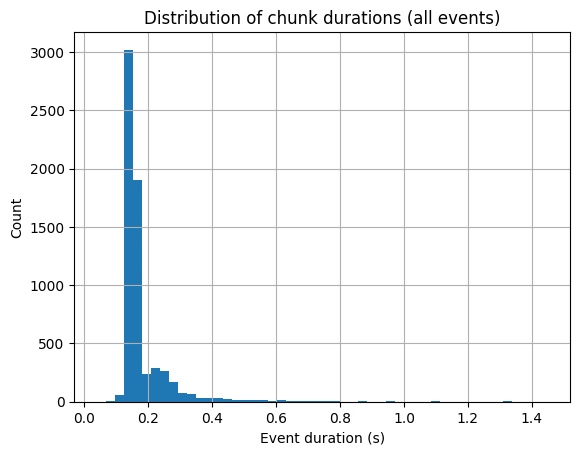

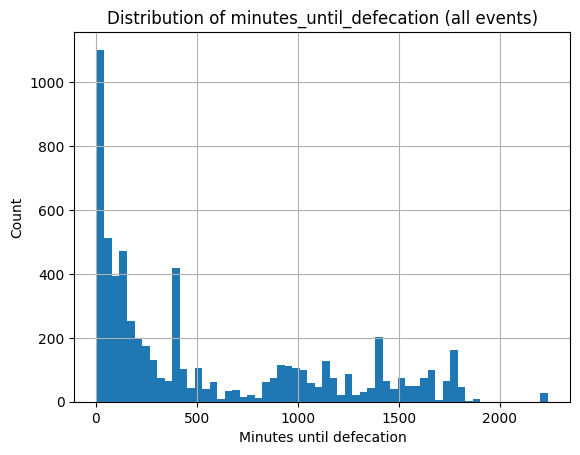

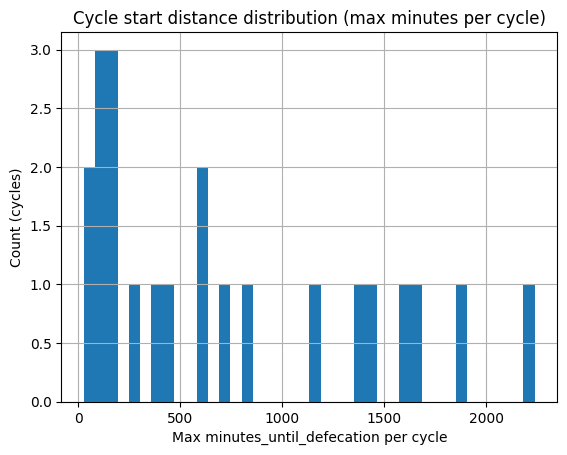

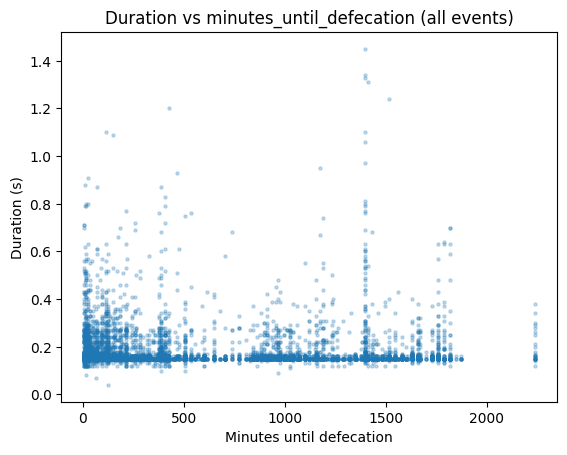

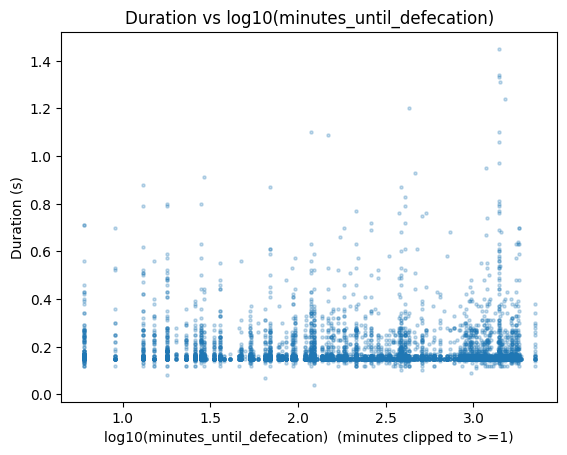

In [ ]:
# 4) Basic metadata inspection + quick plots (CYCLE-AWARE)
# Assumes df already has: session_id, datetime, minutes_until_defecation, duration

import numpy as np
import matplotlib.pyplot as plt

# --- Ensure sorted + build cycles if not already present ---
df = df.sort_values(["session_id", "datetime"]).copy()

if "global_cycle_id" not in df.columns:
    df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
    df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
    df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
    df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

# --- Basic inspection ---
print("Shape (events):", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values (%):\n", (df.isna().mean() * 100).round(2))

n_sessions = df["session_id"].nunique()
n_cycles = df["global_cycle_id"].nunique()
print(f"\nUnique sessions: {n_sessions}")
print(f"Unique defecation cycles (anchors): {n_cycles}")

# How many cycles per session?
cycles_per_session = df.groupby("session_id")["global_cycle_id"].nunique().sort_index()
print("\nCycles per session:\n", cycles_per_session)

# Events per cycle (to see if a few cycles dominate)
events_per_cycle = df.groupby("global_cycle_id").size().sort_values(ascending=False)
print("\nTop 10 cycles by #events:\n", events_per_cycle.head(10))

# --- Duration distribution ---
plt.figure()
df["duration"].dropna().hist(bins=50)
plt.xlabel("Event duration (s)")
plt.ylabel("Count")
plt.title("Distribution of chunk durations (all events)")
plt.show()

# --- minutes_until_defecation distribution ---
plt.figure()
df["minutes_until_defecation"].dropna().hist(bins=60)
plt.xlabel("Minutes until defecation")
plt.ylabel("Count")
plt.title("Distribution of minutes_until_defecation (all events)")
plt.show()

# --- NEW: per-cycle max minutes distribution (sanity: where cycles start) ---
cycle_max = df.groupby("global_cycle_id")["minutes_until_defecation"].max().dropna()
plt.figure()
cycle_max.hist(bins=40)
plt.xlabel("Max minutes_until_defecation per cycle")
plt.ylabel("Count (cycles)")
plt.title("Cycle start distance distribution (max minutes per cycle)")
plt.show()

# --- Duration vs minutes_until_defecation scatter (cycle-aware) ---
tmp = df.dropna(subset=["minutes_until_defecation", "duration"]).copy()

plt.figure()
plt.scatter(tmp["minutes_until_defecation"], tmp["duration"], s=5, alpha=0.25)
plt.xlabel("Minutes until defecation")
plt.ylabel("Duration (s)")
plt.title("Duration vs minutes_until_defecation (all events)")
plt.show()

# --- Optional: log-x view (often reveals structure better) ---
plt.figure()
x = tmp["minutes_until_defecation"].clip(lower=1)  # avoid log(0)
plt.scatter(np.log10(x), tmp["duration"], s=5, alpha=0.25)
plt.xlabel("log10(minutes_until_defecation)  (minutes clipped to >=1)")
plt.ylabel("Duration (s)")
plt.title("Duration vs log10(minutes_until_defecation)")
plt.show()

In [ ]:
df_raw = df.copy()  # keep original

# rows where minutes_until_defecation is NaN
t2d_nan = df_raw[df_raw["minutes_until_defecation"].isna()].copy()
print("Rows with minutes_until_defecation NaN:", len(t2d_nan))
display(t2d_nan[["filename","session_id","datetime","minutes_until_defecation"]].head(50))

print(t2d_nan["session_id"].value_counts(dropna=False))

# now drop
df = df_raw.dropna(subset=["minutes_until_defecation"]).copy()
print("After drop, df rows:", len(df))

Rows with minutes_until_defecation NaN: 32


,filename,session_id,datetime,minutes_until_defecation
7080,11_22_2312_chunk_001.wav,11,2025-11-22 23:12:00,NaN
7081,11_22_2312_chunk_002.wav,11,2025-11-22 23:12:00,NaN
7082,11_22_2312_chunk_003.wav,11,2025-11-22 23:12:00,NaN
7083,11_22_2312_chunk_004.wav,11,2025-11-22 23:12:00,NaN
7084,11_22_2312_chunk_005.wav,11,2025-11-22 23:12:00,NaN
7085,11_22_2312_chunk_006.wav,11,2025-11-22 23:12:00,NaN
7086,11_22_2312_chunk_007.wav,11,2025-11-22 23:12:00,NaN
7087,11_22_2312_chunk_008.wav,11,2025-11-22 23:12:00,NaN
7088,11_22_2312_chunk_009.wav,11,2025-11-22 23:12:00,NaN
7089,11_22_2345_chunk_001.wav,11,2025-11-22 23:45:00,NaN


session_id
11    32
Name: count, dtype: int64
After drop, df rows: 6316


In [ ]:
nan_summary = df_raw.isna().sum()
print(nan_summary[nan_summary > 0].sort_values(ascending=False))

minutes_since_last_defecation    828
minutes_since_meal                64
minute_diff                       42
minutes_until_defecation          32
dtype: int64


In [ ]:
nan_summary = df.isna().sum()
print(nan_summary[nan_summary > 0])

minutes_since_last_defecation    828
minutes_since_meal                64
minute_diff                       10
dtype: int64


Specifically inspect minutes_until_defecation NaNs

In [ ]:
t2d_nan = df[df["minutes_until_defecation"].isna()]
print("Rows with minutes_until_defecation NaN:", len(t2d_nan))
display(t2d_nan[["filename","session_id","datetime","minutes_until_defecation"]].head(20))

Rows with minutes_until_defecation NaN: 0


,filename,session_id,datetime,minutes_until_defecation


In [ ]:
df[df["minutes_until_defecation"].isna()]["session_id"].value_counts()

,count
session_id,


6) Load and visualize a few WAV chunks (waveform + spectrogram + playback)

This will:

find the chunks/ folder

pick a few chunks nearest to defecation (small minutes) if available

plot waveform + spectrogram

Found chunks folders: ['data/chunks']
Using chunks dir: data/chunks

Chosen cycles (closest-first): ['2_0', '3_0', '6_0']

Samples per chosen cycle:
                 count  min  max
global_cycle_id                 
2_0                  3  6.0  6.0
3_0                  3  6.0  6.0
6_0                  3  6.0  6.0

Cycle: 2_0 | File: 10_29_1614_chunk_001.wav | sr=8000 | dur=0.17s | t2d=6.0 min


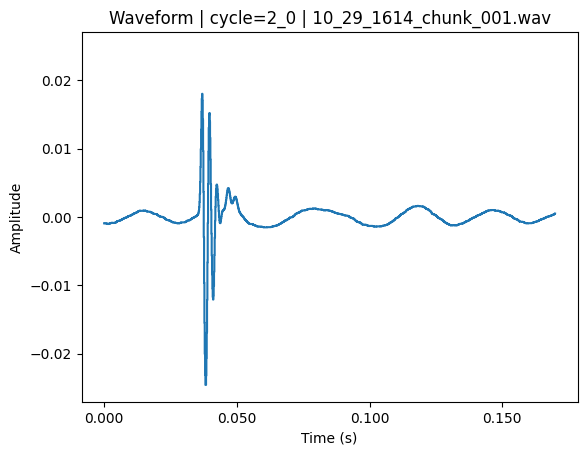

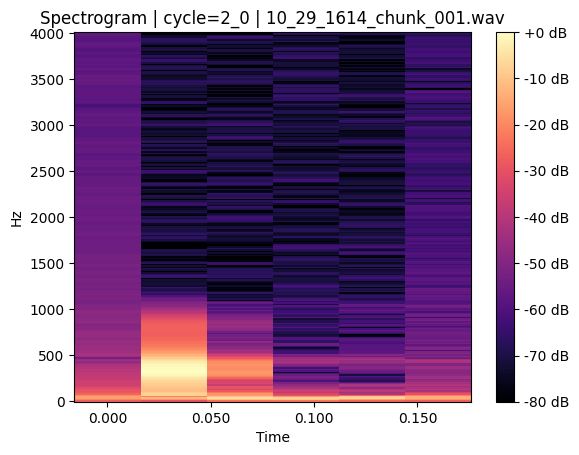


Cycle: 2_0 | File: 10_29_1614_chunk_002.wav | sr=8000 | dur=0.16s | t2d=6.0 min


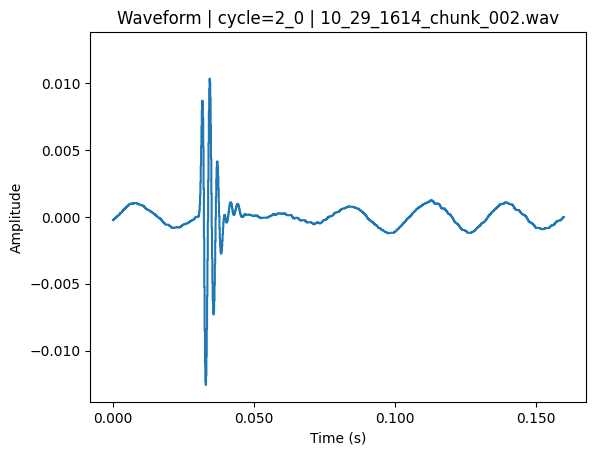

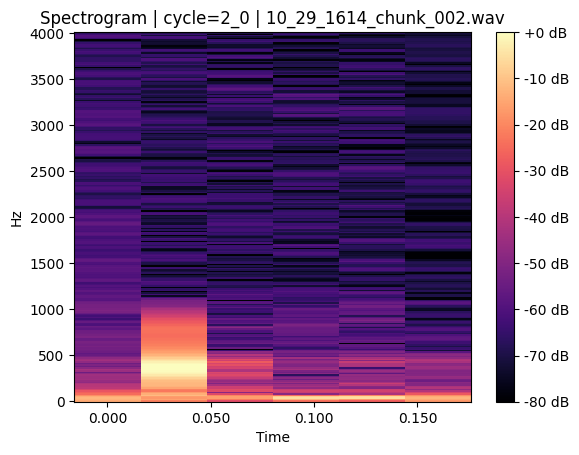


Cycle: 2_0 | File: 10_29_1614_chunk_003.wav | sr=8000 | dur=0.16s | t2d=6.0 min


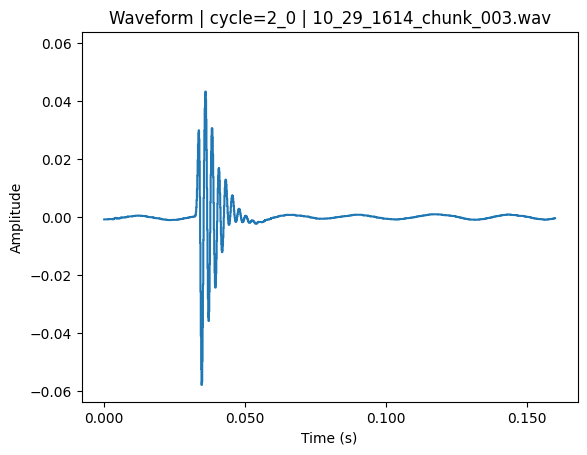

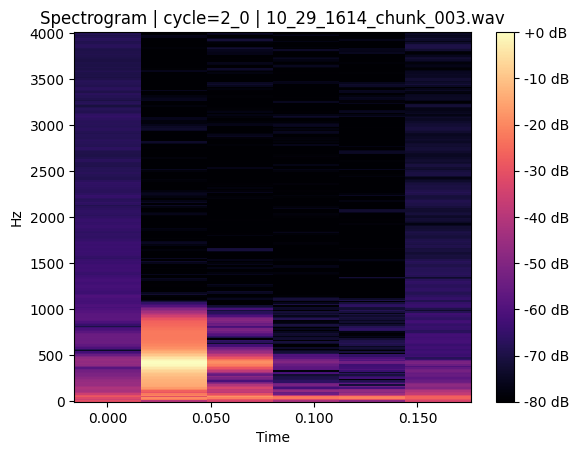


Cycle: 3_0 | File: 10_30_1824_chunk_001.wav | sr=8000 | dur=0.17s | t2d=6.0 min


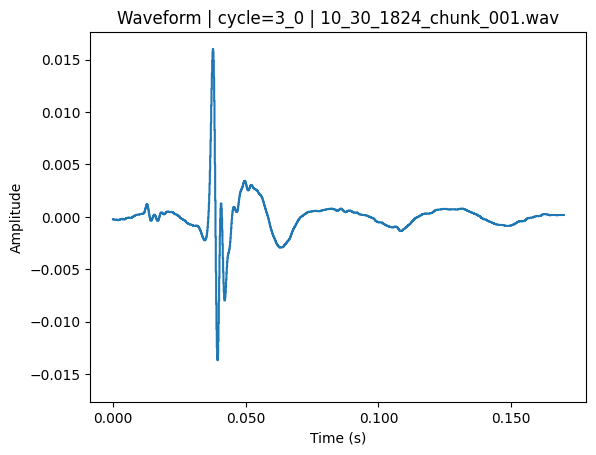

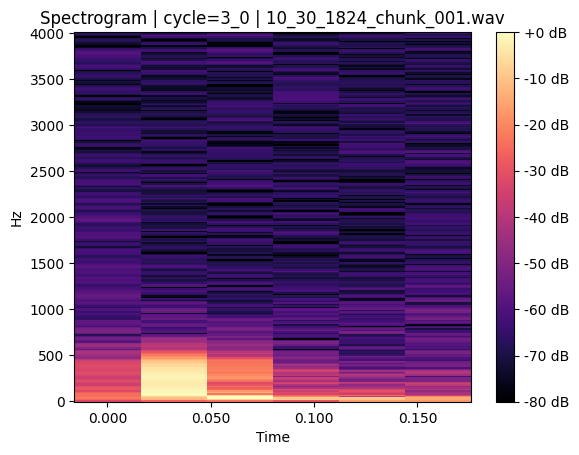


Cycle: 3_0 | File: 10_30_1824_chunk_002.wav | sr=8000 | dur=0.17s | t2d=6.0 min


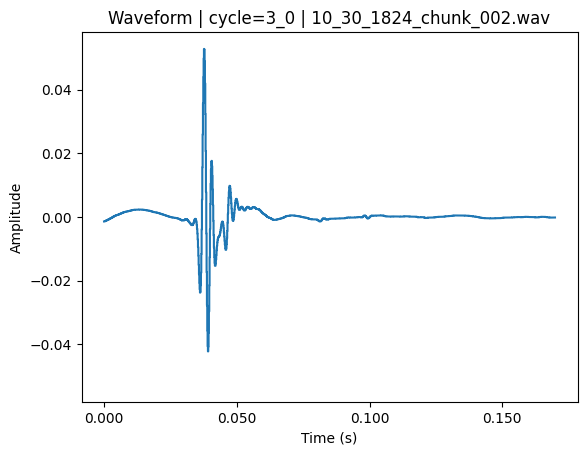

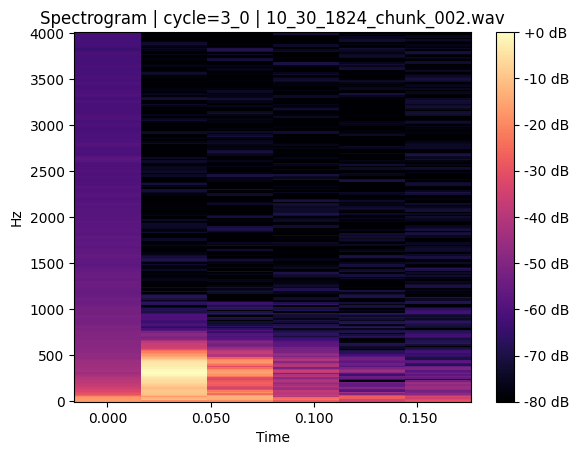


Cycle: 3_0 | File: 10_30_1824_chunk_003.wav | sr=8000 | dur=0.26s | t2d=6.0 min


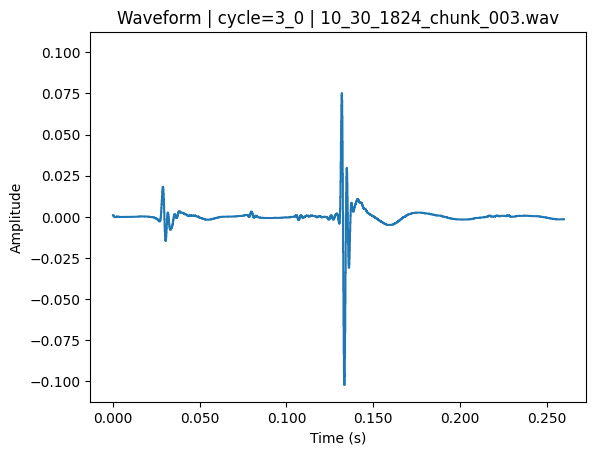

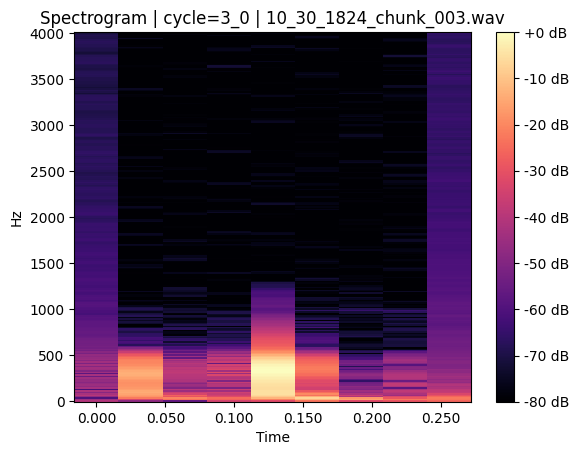


Cycle: 6_0 | File: 11_3_1746_chunk_001.wav | sr=8000 | dur=0.15s | t2d=6.0 min


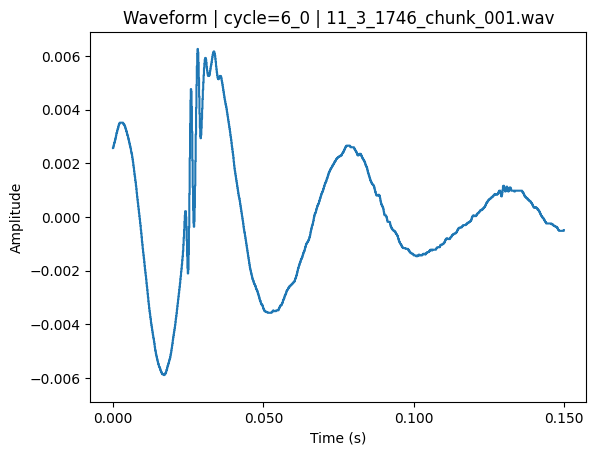

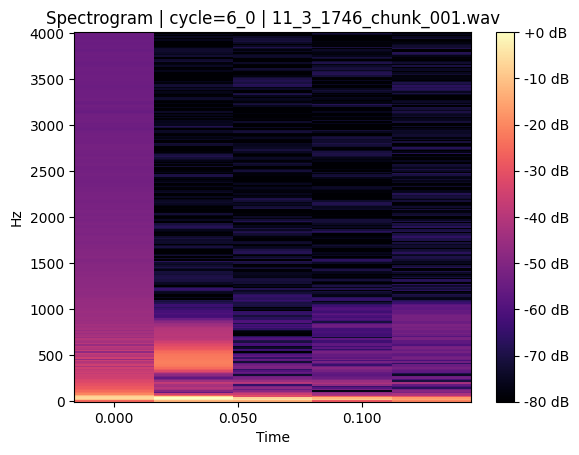


Cycle: 6_0 | File: 11_3_1746_chunk_002.wav | sr=8000 | dur=0.15s | t2d=6.0 min


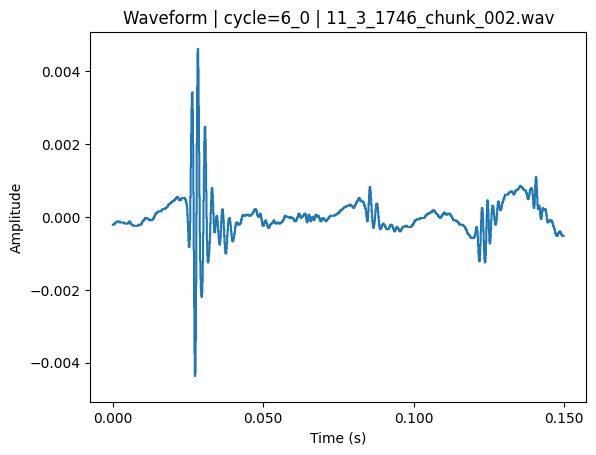

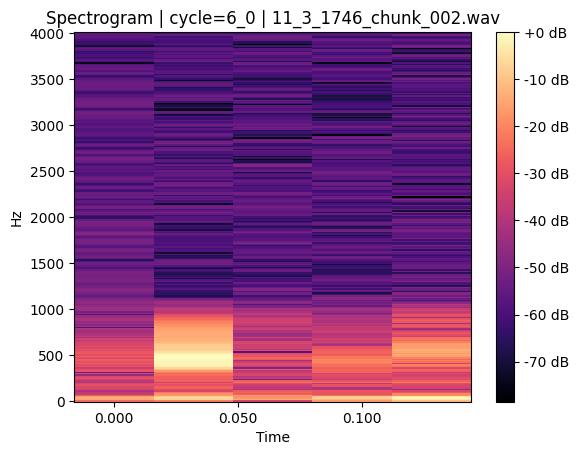


Cycle: 6_0 | File: 11_3_1746_chunk_003.wav | sr=8000 | dur=0.15s | t2d=6.0 min


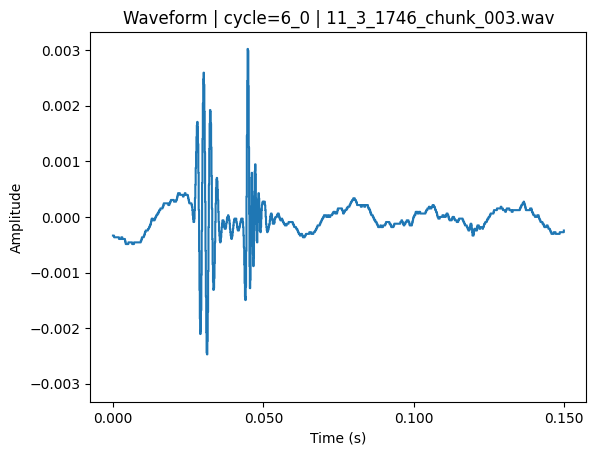

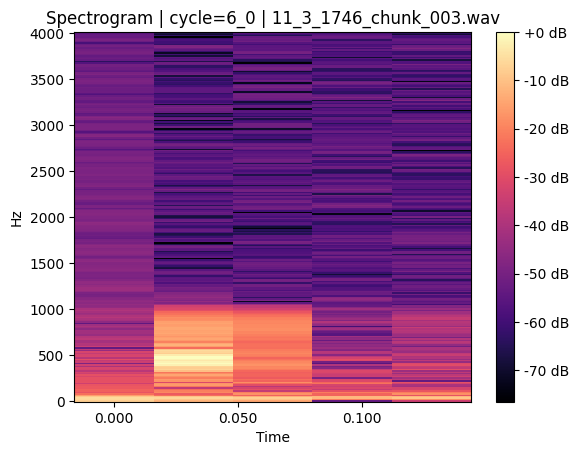

In [ ]:
# 6) Load and visualize WAV chunks (CYCLE-AWARE)
# - Finds chunks/ folder
# - Picks a few cycles and within each cycle picks chunks nearest to defecation
# - Plots waveform + spectrogram + playback

import os, glob
import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from IPython.display import Audio, display

# ---------- Ensure cycle columns exist ----------
df = df.sort_values(["session_id", "datetime"]).copy()

if "global_cycle_id" not in df.columns:
    df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
    df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
    df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
    df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

# ---------- Find chunks folder ----------
chunks_dirs = [p for p in glob.glob("**/chunks", recursive=True) if os.path.isdir(p)]
print("Found chunks folders:", chunks_dirs)

if not chunks_dirs:
    print("No chunks/ folder found. Upload wav files or unzip dataset folder containing chunks/")
else:
    chunks_dir = chunks_dirs[0]
    print("Using chunks dir:", chunks_dir)

    # ---------- Choose samples cycle-aware ----------
    has_t2d = ("minutes_until_defecation" in df.columns) and df["minutes_until_defecation"].notna().any()
    if not has_t2d:
        # Fallback: random files if target missing
        sample_df = df.sample(10, random_state=42)
        chosen = sample_df
        print("\nminutes_until_defecation not available -> using random samples.")
    else:
        # Choose cycles first, then take nearest-to-defecation K samples per cycle
        N_CYCLES = 3          # how many cycles to inspect
        K_PER_CYCLE = 3       # how many nearest samples per cycle
        MAX_MINUTES = 60      # focus window near defecation (set None to disable)

        working = df.dropna(subset=["minutes_until_defecation", "filename", "global_cycle_id"]).copy()

        if MAX_MINUTES is not None:
            working = working[working["minutes_until_defecation"] <= MAX_MINUTES]

        # If too few near-defecation rows, relax window automatically
        if working.empty:
            print(f"\nNo events found within <= {MAX_MINUTES} minutes. Relaxing filter to use global nearest samples.")
            working = df.dropna(subset=["minutes_until_defecation", "filename", "global_cycle_id"]).copy()

        # pick cycles that actually have data
        cycle_order = (
            working.groupby("global_cycle_id")["minutes_until_defecation"]
                   .min()
                   .sort_values()
                   .index.tolist()
        )
        chosen_cycles = cycle_order[:N_CYCLES]

        chosen = (
            working[working["global_cycle_id"].isin(chosen_cycles)]
            .sort_values(["global_cycle_id", "minutes_until_defecation"])
            .groupby("global_cycle_id", group_keys=False)
            .head(K_PER_CYCLE)
        )

        print("\nChosen cycles (closest-first):", chosen_cycles)
        print("\nSamples per chosen cycle:")
        print(chosen.groupby("global_cycle_id")["minutes_until_defecation"].agg(["count", "min", "max"]))

    # ---------- Visualize ----------
    for idx, row in chosen.iterrows():
        wav_path = os.path.join(chunks_dir, row["filename"])
        if not os.path.exists(wav_path):
            print("Missing wav:", wav_path)
            continue

        y, sr = librosa.load(wav_path, sr=None, mono=True)

        print(
            f"\nCycle: {row.get('global_cycle_id', 'NA')} | "
            f"File: {row['filename']} | sr={sr} | dur={len(y)/sr:.2f}s | "
            f"t2d={row.get('minutes_until_defecation', None)} min"
        )

        # Waveform
        plt.figure()
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform | cycle={row.get('global_cycle_id', 'NA')} | {row['filename']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

        # Spectrogram (dB)
        n_fft = 512
        hop = 256
        S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop))
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        plt.figure()
        librosa.display.specshow(S_db, sr=sr, hop_length=hop, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram | cycle={row.get('global_cycle_id', 'NA')} | {row['filename']}")
        plt.show()

        # Playback
        display(Audio(y, rate=sr))

In [ ]:
import os
import pandas as pd

# ---------------------------
# Step 0: Dataset paths (robust)
# ---------------------------
# Option A: If you know the folder name, keep it:
DATASET_ROOT = "data"

# Option B (recommended): auto-detect dataset root containing dataset_metadata.csv
if not os.path.exists(os.path.join(DATASET_ROOT, "dataset_metadata.csv")):
    candidates = []
    for root, dirs, files in os.walk("."):
        if "dataset_metadata.csv" in files:
            candidates.append(root)
    if candidates:
        # choose the shortest path (usually the top-most dataset folder)
        DATASET_ROOT = sorted(candidates, key=len)[0]

META_PATH  = os.path.join(DATASET_ROOT, "dataset_metadata.csv")
CHUNKS_DIR = os.path.join(DATASET_ROOT, "chunks")

print("Using DATASET_ROOT:", DATASET_ROOT)
print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))


# ---------------------------
# Step 2: Keep events with valid minutes_until_defecation (CYCLE-AWARE)
# ---------------------------

df2 = df.copy()

# Ensure datetime is parsed for correct ordering
df2["datetime"] = pd.to_datetime(df2["datetime"], errors="coerce")

# Keep rows with valid target
df2 = df2[df2["minutes_until_defecation"].notna()].copy()
df2["minutes_until_defecation"] = df2["minutes_until_defecation"].astype(float)

# Sort before cycle detection
df2 = df2.sort_values(["session_id", "datetime"]).copy()

# ---- Build cycles (defecation-anchor segments) ----
df2["minute_diff"] = df2.groupby("session_id")["minutes_until_defecation"].diff()
df2["new_cycle_flag"] = (df2["minute_diff"] > 0).astype(int)
df2["cycle_id"] = df2.groupby("session_id")["new_cycle_flag"].cumsum()
df2["global_cycle_id"] = df2["session_id"].astype(str) + "_" + df2["cycle_id"].astype(str)

print("\nEvents with target:", len(df2))
print("Target range (min):", df2["minutes_until_defecation"].min(), "to", df2["minutes_until_defecation"].max())

print("\nUnique sessions:", df2["session_id"].nunique())
print("Unique cycles (defecation anchors):", df2["global_cycle_id"].nunique())

print("\nCycles per session:")
print(df2.groupby("session_id")["global_cycle_id"].nunique().sort_index())

# Quick peek
cols = ["filename", "session_id", "global_cycle_id", "datetime", "minutes_until_defecation", "duration"]
print("\nPreview:")
display(df2[cols].head())

Using DATASET_ROOT: data
META exists: True
CHUNKS dir exists: True

Events with target: 6316
Target range (min): 6.0 to 2238.0

Unique sessions: 10
Unique cycles (defecation anchors): 22

Cycles per session:
session_id
1     1
2     3
3     2
4     3
5     2
6     3
8     1
9     4
10    2
11    1
Name: global_cycle_id, dtype: int64

Preview:


,filename,session_id,global_cycle_id,datetime,minutes_until_defecation,duration
0,10_28_1629_chunk_001.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.15
1,10_28_1629_chunk_002.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.20
2,10_28_1629_chunk_003.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.15
3,10_28_1629_chunk_004.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.17
4,10_28_1629_chunk_005.wav,1,1_0,2025-10-28 16:29:00,1431.0,0.16


# UPDATED CODE SET 4 (Cycle-aware)

In [ ]:
# ============================================================
# CODE SET 4 (Merged) - UPDATED to CYCLE-AWARE
# ============================================================

# -------------------------
# 1) Paths + Output
OUT_DIR = "results_code_set4"
os.makedirs(OUT_DIR, exist_ok=True)

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))

# -------------------------
# 2) Global Parameters
# -------------------------
OUTLIER_SESSION_ID = 7
DROP_OUTLIER_SESSION = True

SESSIONS_TO_REMOVE = [1, 8, 9]

HP_CUTOFF_HZ = 20
HP_ORDER = 2

STFT_WINDOW = "hann"
STFT_BASE_NFFT_16K = 1024
STFT_BASE_NFFT_8K = 512
MIN_SPECTRAL_NPERSEG = 32

bins = [0, 30, 60, 120, 240, 360, 480, 720, 1440, 999999]
labels_near_to_far = ["0-30m","30-60m","1-2h","2-4h","4-6h","6-8h","8-12h","12-24h",">24h"]
order_far_to_near = [">24h","12-24h","8-12h","6-8h","4-6h","2-4h","1-2h","30-60m","0-30m"]

BASELINE_MIN = 480
MIN_BASELINE_N = 10

NEAR_MAX = 60
FAR_MIN = 480

Z_FEATURES = ["feat_centroid_mean", "feat_flatness_mean", "feat_duration_s", "feat_env_mean", "feat_zcr"]

# -------------------------
# 3) Utility Functions
# -------------------------
def teager_kaiser_energy(x):
    x = np.asarray(x)
    if len(x) < 3:
        return np.array([0.0])
    return x[1:-1]**2 - x[:-2] * x[2:]

def highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER):
    if len(x) < 64 or sr < 100:
        return x
    b, a = signal.butter(order, cutoff_hz / (sr / 2), btype="highpass")
    return signal.filtfilt(b, a, x)

def add_bins(df_):
    df_ = df_.copy()
    df_["t2d_bin"] = pd.cut(
        df_["minutes_until_defecation"],
        bins=bins,
        labels=labels_near_to_far,
        include_lowest=True
    )
    df_["t2d_bin"] = pd.Categorical(df_["t2d_bin"],
                                    categories=order_far_to_near,
                                    ordered=True)
    return df_

def rank_biserial_from_U(U, n1, n2):
    return 1 - (2 * U) / (n1 * n2)

def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    gt = 0
    lt = 0
    for x in a:
        gt += np.sum(x > b)
        lt += np.sum(x < b)
    return (gt - lt) / (len(a) * len(b))

def bootstrap_ci_median(x, n_boot=800, ci=95, seed=42):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    meds = []
    for _ in range(n_boot):
        samp = rng.choice(x, size=len(x), replace=True)
        meds.append(np.median(samp))
    lo = np.percentile(meds, (100-ci)/2)
    hi = np.percentile(meds, 100-(100-ci)/2)
    return np.median(x), lo, hi

def _rolloff95(f, M):
    cumsum = np.cumsum(M, axis=0)
    total = cumsum[-1, :] + 1e-12
    T = cumsum.shape[1]
    roll = np.zeros(T, dtype=np.float32)
    for i in range(T):
        idx = np.searchsorted(cumsum[:, i], 0.95 * total[i])
        idx = min(idx, len(f) - 1)
        roll[i] = f[idx]
    return roll

# -------------------------
# 4) Hybrid Feature Extraction
# -------------------------
def extract_features_hybrid(wav_path):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    x = highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER)

    dur = len(x) / sr
    rms = float(np.sqrt(np.mean(x**2) + 1e-12))
    peak = float(np.max(np.abs(x)) + 1e-12)
    zcr = float(np.mean(np.abs(np.diff(np.sign(x))) > 0))
    peak_to_rms = float(peak / (rms + 1e-12))

    env = np.abs(signal.hilbert(x)) + 1e-12
    env_mean = float(np.mean(env))
    env_std = float(np.std(env))
    env_max = float(np.max(env))
    env_crest = float(env_max / (env_mean + 1e-12))

    base_n_fft = STFT_BASE_NFFT_16K if sr >= 16000 else STFT_BASE_NFFT_8K
    nperseg = min(base_n_fft, len(x))

    if nperseg < MIN_SPECTRAL_NPERSEG:
        centroid = np.array([0.0])
        flatness = np.array([0.0])
        roll95_amp = np.array([0.0])
        roll95_pow = np.array([0.0])
        flux_mean = 0.0
    else:
        hop = max(1, nperseg // 4)
        noverlap = min(nperseg - 1, nperseg - hop)

        f, t, Z = signal.stft(
            x,
            fs=sr,
            nperseg=nperseg,
            noverlap=noverlap,
            window=STFT_WINDOW,
            padded=False,
            boundary=None
        )
        mag = np.abs(Z) + 1e-12
        pow_ = mag**2

        centroid = (f[:, None] * mag).sum(axis=0) / mag.sum(axis=0)
        flatness = np.exp(np.mean(np.log(mag), axis=0)) / (np.mean(mag, axis=0) + 1e-12)

        roll95_amp = _rolloff95(f, mag)
        roll95_pow = _rolloff95(f, pow_)

        flux = np.sqrt(np.sum(np.diff(mag, axis=1)**2, axis=0))
        flux_mean = float(np.mean(flux)) if flux.size else 0.0

    tkeo = np.abs(teager_kaiser_energy(x))
    tkeo_mean = float(np.mean(tkeo)) if tkeo.size else 0.0
    tkeo_max = float(np.max(tkeo)) if tkeo.size else 0.0

    return {
        "sr": int(sr),
        "feat_duration_s": float(dur),
        "feat_rms": rms,
        "feat_log_rms": float(np.log(rms + 1e-12)),
        "feat_peak_to_rms": peak_to_rms,
        "feat_zcr": zcr,
        "feat_env_mean": env_mean,
        "feat_env_std": env_std,
        "feat_env_crest": env_crest,
        "feat_centroid_mean": float(np.mean(centroid)),
        "feat_centroid_std": float(np.std(centroid)),
        "feat_flatness_mean": float(np.mean(flatness)),
        "feat_roll95_amp_mean": float(np.mean(roll95_amp)),
        "feat_roll95_pow_mean": float(np.mean(roll95_pow)),
        "feat_flux_mean": flux_mean,
        "feat_tkeo_mean": tkeo_mean,
        "feat_tkeo_max": tkeo_max,
        "stft_nperseg": int(nperseg),
        "stft_hop": int(max(1, nperseg // 4)) if nperseg >= MIN_SPECTRAL_NPERSEG else 0,
        "stft_window": STFT_WINDOW,
        "hp_cutoff_hz": HP_CUTOFF_HZ,
        "hp_order": HP_ORDER,
    }

# -------------------------
# 5) Load metadata safely + Filtering
# -------------------------
df_raw = pd.read_csv(META_PATH)
print("Rows raw:", len(df_raw), "Sessions raw:", df_raw["session_id"].nunique())

df = df_raw.copy()

# Parse datetime EARLY (important for correct cycle detection)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Remove outlier session 7
if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    df = df[df["session_id"] != OUTLIER_SESSION_ID].copy()
    print("Removed session:", OUTLIER_SESSION_ID)

if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    assert OUTLIER_SESSION_ID not in df["session_id"].unique(), "Session 7 leaked back into df!"

print("Rows after removing 7:", len(df), "Sessions:", df["session_id"].nunique())

# Remove sessions 1, 8, 9 and store separately
df_removed_1_8_9 = df[df["session_id"].isin(SESSIONS_TO_REMOVE)].copy()
df_clean = df[~df["session_id"].isin(SESSIONS_TO_REMOVE)].copy()

print("\nRemoved sessions stored separately:", sorted(df_removed_1_8_9["session_id"].unique()))
print("Rows in removed set:", len(df_removed_1_8_9))

print("\nRows after removing 1,8,9:", len(df_clean))
print("Sessions after:", sorted(df_clean["session_id"].unique()))

df = df_clean

# Keep valid target
df = df.dropna(subset=["minutes_until_defecation"]).copy()
df["minutes_until_defecation"] = df["minutes_until_defecation"].astype(float)

# Sort (required for cycle boundaries)
df = df.sort_values(["session_id", "datetime"]).copy()
print("\nRows with valid minutes_until_defecation:", len(df))

# -------------------------
# 5.5) NEW: Build defecation cycles inside sessions
# -------------------------
df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

print("\nUnique sessions:", df["session_id"].nunique())
print("Unique defecation cycles (anchors):", df["global_cycle_id"].nunique())
print("\nCycles per session:\n", df.groupby("session_id")["global_cycle_id"].nunique().sort_index())

# -------------------------
# 6) Extract features for ALL events (global dataset)
# -------------------------
feature_rows = []
missing = 0

for _, row in df.iterrows():
    wav_path = os.path.join(CHUNKS_DIR, row["filename"])
    if not os.path.exists(wav_path):
        missing += 1
        continue
    feats = extract_features_hybrid(wav_path)
    feats["filename"] = row["filename"]
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print("Extracted feature rows:", len(feat_df), "Missing wavs:", missing)

data = df.merge(feat_df, on="filename", how="inner")
print("Merged rows:", len(data))

global_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4.csv")
data.to_csv(global_csv, index=False)
print("Saved global features:", global_csv)

# -------------------------
# 7) Global Binning (far -> near)
# -------------------------
data = add_bins(data)
bin_counts = data["t2d_bin"].value_counts().sort_index()
print("\nBin counts (far -> near):")
print(bin_counts)

# -------------------------
# 8) CYCLE-NORMALIZATION (z-scores)  <<<<< CHANGED HERE
# -------------------------
data_norm = data.copy()
for f in Z_FEATURES:
    data_norm[f + "_z"] = np.nan
data_norm["baseline_n"] = 0

def cycle_zscore(df_cycle):
    df_cycle = df_cycle.copy()
    base = df_cycle[df_cycle["minutes_until_defecation"] >= BASELINE_MIN]
    df_cycle["baseline_n"] = len(base)

    if len(base) < MIN_BASELINE_N:
        return df_cycle

    mu = base[Z_FEATURES].mean()
    sd = base[Z_FEATURES].std(ddof=0).replace(0, np.nan)

    for f in Z_FEATURES:
        df_cycle[f + "_z"] = (df_cycle[f] - mu[f]) / sd[f]
    return df_cycle

# IMPORTANT: group by global_cycle_id now
data_norm = data_norm.groupby("global_cycle_id", group_keys=False).apply(cycle_zscore)
data_norm = add_bins(data_norm)

norm_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4_norm.csv")
data_norm.to_csv(norm_csv, index=False)
print("Saved normalized features:", norm_csv)

# -------------------------
# 9) Global Stats Table (same global, but now data has cycles)
# -------------------------
feature_cols = [c for c in data.columns if c.startswith("feat_") and not c.endswith("_z")]

tmp = data.dropna(subset=["minutes_until_defecation"]).copy()
near_df = tmp[tmp["minutes_until_defecation"] <= NEAR_MAX]
far_df  = tmp[tmp["minutes_until_defecation"] >= FAR_MIN]
print("\nNear N:", len(near_df), "Far N:", len(far_df))

rows = []
for feat in feature_cols:
    t = tmp.dropna(subset=[feat, "minutes_until_defecation"])
    if len(t) < 20:
        rho, p_s = np.nan, np.nan
    else:
        rho, p_s = stats.spearmanr(t[feat].values, t["minutes_until_defecation"].values)

    a = near_df[feat].dropna().values
    b = far_df[feat].dropna().values
    if len(a) < 30 or len(b) < 30:
        mw_p = np.nan
        rbc = np.nan
        cd = np.nan
    else:
        U, mw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rbc = rank_biserial_from_U(U, len(a), len(b))
        cd = cliffs_delta(a, b)

    rows.append({
        "feature": feat,
        "spearman_rho": rho,
        "spearman_p": p_s,
        "mw_p": mw_p,
        "rank_biserial": rbc,
        "cliffs_delta": cd,
        "near_N": len(a),
        "far_N": len(b),
    })

stats_df = pd.DataFrame(rows).sort_values("mw_p")
stats_csv = os.path.join(OUT_DIR, "global_stats_codeset4.csv")
stats_df.to_csv(stats_csv, index=False)
print("\nSaved global stats:", stats_csv)

# -------------------------
# 10) Global Plots (Raw medians)
# -------------------------
top_feats = stats_df.sort_values("spearman_p").head(6)["feature"].tolist()

for c in top_feats:
    grp = data.groupby("t2d_bin", observed=True)[c].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(f"Global median: {c} (far -> near)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(c)
    plt.xticks(rotation=45)
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_raw_{c}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

# -------------------------
# 11) Global Plots (Z-score medians + bootstrap CI) [now cycle-normalized]
# -------------------------
important_feats_z = ["feat_centroid_mean_z", "feat_flatness_mean_z", "feat_duration_s_z"]

for fz in important_feats_z:
    rows_ci = []
    for b in order_far_to_near:
        vals = data_norm.loc[data_norm["t2d_bin"] == b, fz].values
        med, lo, hi = bootstrap_ci_median(vals, n_boot=800, ci=95, seed=42)
        rows_ci.append((b, med, lo, hi, np.sum(~np.isnan(vals))))
    plot_df = pd.DataFrame(rows_ci, columns=["bin","median","ci_low","ci_high","N"])

    plt.figure()
    plt.errorbar(
        plot_df["bin"],
        plot_df["median"],
        yerr=[plot_df["median"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["median"]],
        fmt="o-"
    )
    plt.axhline(0, linestyle="--", color="gray", label="Baseline (z=0)")
    plt.title(f"Global cycle-normalized {fz} (median ± 95% bootstrap CI)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel("z-score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_z_{fz}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

    ci_csv = os.path.join(OUT_DIR, f"global_ci_{fz}.csv")
    plot_df.to_csv(ci_csv, index=False)

# -------------------------
# 12) Per-CYCLE outputs + Cycle Summary  <<<<< CHANGED HERE
# -------------------------
CYCLE_SUMMARY = []
all_cycles = sorted(data["global_cycle_id"].unique())

def plot_trend(df_, col, title, outpng):
    grp = df_.groupby("t2d_bin", observed=True)[col].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(title)
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(outpng, dpi=150)
    plt.close()

for cid in all_cycles:
    cyc_dir = os.path.join(OUT_DIR, f"cycle_{cid}")
    os.makedirs(cyc_dir, exist_ok=True)

    df_cyc = data[data["global_cycle_id"] == cid].copy()
    df_cyc = add_bins(df_cyc)

    # apply cycle zscore
    df_cyc_norm = cycle_zscore(df_cyc)

    csv_path = os.path.join(cyc_dir, f"features_cycle_{cid}.csv")
    df_cyc_norm.to_csv(csv_path, index=False)

    # Raw plots
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col in df_cyc_norm.columns:
            outpng = os.path.join(cyc_dir, f"raw_{col}.png")
            plot_trend(df_cyc_norm, col, f"Cycle {cid} raw median: {col}", outpng)

    # Z plots
    for col in [f + "_z" for f in Z_FEATURES]:
        if col in df_cyc_norm.columns:
            outpng = os.path.join(cyc_dir, f"z_{col}.png")
            plot_trend(df_cyc_norm, col, f"Cycle {cid} z-score median: {col}", outpng)

    # Spearman within cycle
    scores = {}
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col not in df_cyc_norm.columns:
          continue
        tmp_c = df_cyc_norm.dropna(subset=[col, "minutes_until_defecation"])
        if len(tmp_c) < 20:
            rho, p = np.nan, np.nan
        else:
            rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
        scores[col + "_rho"] = rho
        scores[col + "_p"] = p

    baseline_n = int(df_cyc_norm["baseline_n"].iloc[0]) if "baseline_n" in df_cyc_norm.columns else 0
    sid = int(df_cyc_norm["session_id"].iloc[0]) if "session_id" in df_cyc_norm.columns else None

    CYCLE_SUMMARY.append({
        "global_cycle_id": cid,
        "session_id": sid,
        "N_events": len(df_cyc_norm),
        "baseline_n": baseline_n,
        **scores,
        "csv_path": csv_path
    })

cycle_summary_df = pd.DataFrame(CYCLE_SUMMARY).sort_values(["session_id", "global_cycle_id"])
cycle_summary_csv = os.path.join(OUT_DIR, "cycle_summary_codeset4.csv")
cycle_summary_df.to_csv(cycle_summary_csv, index=False)

print("\nDone. Saved per-cycle outputs + cycle summary:")
print(cycle_summary_csv)
print(cycle_summary_df.head(10))

# -------------------------
# 13) Sign consistency across CYCLES (not sessions)
# -------------------------
def sign_consistency(summary_df, rho_col):
    vals = summary_df[rho_col].dropna().values
    pos = np.sum(vals > 0)
    neg = np.sum(vals < 0)
    return int(pos), int(neg), int(len(vals))

if "feat_centroid_mean_rho" in cycle_summary_df.columns:
    pos, neg, n = sign_consistency(cycle_summary_df, "feat_centroid_mean_rho")
    print(f"\nCentroid Spearman sign consistency across cycles: +{pos}, -{neg}, total_valid={n}")

print("\nAll outputs are inside:", OUT_DIR)

META exists: True
CHUNKS dir exists: True
Rows raw: 7112 Sessions raw: 11
Removed session: 7
Rows after removing 7: 6348 Sessions: 10

Removed sessions stored separately: [np.int64(1), np.int64(8), np.int64(9)]
Rows in removed set: 1477

Rows after removing 1,8,9: 4871
Sessions after: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(10), np.int64(11)]

Rows with valid minutes_until_defecation: 4839

Unique sessions: 7
Unique defecation cycles (anchors): 16

Cycles per session:
 session_id
2     3
3     2
4     3
5     2
6     3
10    2
11    1
Name: global_cycle_id, dtype: int64
Extracted feature rows: 4839 Missing wavs: 0
Merged rows: 4839
Saved global features: results_code_set4/bowel_event_features_codeset4.csv

Bin counts (far -> near):
t2d_bin
>24h      550
12-24h    550
8-12h     287
6-8h      581
4-6h      388
2-4h      680
1-2h      714
30-60m    308
0-30m     781
Name: count, dtype: int64


/tmp/ipykernel_1503/2113331607.py:305: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_norm = data_norm.groupby("global_cycle_id", group_keys=False).apply(cycle_zscore)


Saved normalized features: results_code_set4/bowel_event_features_codeset4_norm.csv

Near N: 1089 Far N: 1387

Saved global stats: results_code_set4/global_stats_codeset4.csv


/tmp/ipykernel_1503/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_1503/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_1503/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_1503/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_1503/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], 


Done. Saved per-cycle outputs + cycle summary:
results_code_set4/cycle_summary_codeset4.csv
   global_cycle_id  session_id  N_events  baseline_n  feat_centroid_mean_rho  \
3              2_0           2       189           0                0.206805   
4              2_1           2       406           0               -0.090040   
5              2_2           2       136         136               -0.109753   
6              3_0           3       191           0                0.171919   
7              3_1           3       300         300                0.038865   
8              4_0           4       247           0                0.169350   
9              4_1           4       145           0                0.305976   
10             4_2           4       477         477               -0.101342   
11             5_0           5       390         102                0.208708   
12             5_1           5        27          27                     NaN   

    feat_centroid_mean_p  

check the clustreting method from earlier chat of --c liffs delta

In [ ]:
rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])

In [ ]:
from scipy import stats
import numpy as np

print("="*60)
print("CYCLE-LEVEL SPEARMAN NaN DIAGNOSTIC")
print("="*60)

# ------------------------------------------------
# 1️⃣ Cycles where centroid rho is NaN
# ------------------------------------------------
nan_centroid = cycle_summary_df[
    cycle_summary_df["feat_centroid_mean_rho"].isna()
][["global_cycle_id", "session_id", "N_events", "baseline_n"]]

print("\n[1] Cycles with NaN centroid Spearman:")
print(nan_centroid)
print("Count:", len(nan_centroid))


# ------------------------------------------------
# 2️⃣ Cycles where ANY feature rho is NaN
# ------------------------------------------------
rho_cols = [c for c in cycle_summary_df.columns if c.endswith("_rho")]

nan_any = cycle_summary_df[
    cycle_summary_df[rho_cols].isna().any(axis=1)
][["global_cycle_id", "session_id", "N_events", "baseline_n"] + rho_cols]

print("\n[2] Cycles with NaN in ANY rho feature:")
print(nan_any[["global_cycle_id", "session_id", "N_events", "baseline_n"]])
print("Count:", len(nan_any))


# ------------------------------------------------
# 3️⃣ Identify WHY Spearman is NaN
# ------------------------------------------------
def explain_nan_reason(cid, feature="feat_centroid_mean"):
    df_c = data[data["global_cycle_id"] == cid].copy()

    # remove NaNs only for that test
    df_c = df_c.dropna(subset=[feature, "minutes_until_defecation"])

    n = len(df_c)
    uniq_feat = df_c[feature].nunique(dropna=True)
    uniq_t2d = df_c["minutes_until_defecation"].nunique(dropna=True)

    reasons = []
    if n < 3:
        reasons.append(f"Too few valid points (n={n})")
    if uniq_feat <= 1:
        reasons.append("Feature constant")
    if uniq_t2d <= 1:
        reasons.append("Time variable constant")

    return n, uniq_feat, uniq_t2d, reasons


print("\n[3] Reason analysis for centroid-NaN cycles:")
for cid in nan_centroid["global_cycle_id"].tolist():
    n, uf, ut, reasons = explain_nan_reason(cid, "feat_centroid_mean")
    print(f"\nCycle {cid}")
    print(f"  Valid points: {n}")
    print(f"  Unique centroid values: {uf}")
    print(f"  Unique time values: {ut}")
    print(f"  Reason(s): {reasons if reasons else 'Unknown (check raw data)'}")

print("\n" + "="*60)
print("END OF DIAGNOSTIC")
print("="*60)

CYCLE-LEVEL SPEARMAN NaN DIAGNOSTIC

[1] Cycles with NaN centroid Spearman:
   global_cycle_id  session_id  N_events  baseline_n
12             5_1           5        27          27
15             6_2           6         1           1
Count: 2

[2] Cycles with NaN in ANY rho feature:
   global_cycle_id  session_id  N_events  baseline_n
12             5_1           5        27          27
15             6_2           6         1           1
Count: 2

[3] Reason analysis for centroid-NaN cycles:

Cycle 5_1
  Valid points: 27
  Unique centroid values: 27
  Unique time values: 1
  Reason(s): ['Time variable constant']

Cycle 6_2
  Valid points: 1
  Unique centroid values: 1
  Unique time values: 1
  Reason(s): ['Too few valid points (n=1)', 'Feature constant', 'Time variable constant']

END OF DIAGNOSTIC


In [ ]:
# ================================
# V5 → CYCLE-BASED VERSION
# Bins: 4-6h, 2-4h, 1-2h, 30-60m, 0-30m
# ================================

import os
import numpy as np
import pandas as pd
from scipy import signal
import soundfile as sf
import plotly.express as px

# -------------------------
# STEP 1: Isolate ONLY those chunks (no reprocessing)
# -------------------------
bins_of_interest = ["4-6h", "2-4h", "1-2h", "30-60m", "0-30m"]

sub = data[data["t2d_bin"].isin(bins_of_interest)].copy()

assert "global_cycle_id" in sub.columns, "global_cycle_id missing in data!"
print("Event counts per bin:")
print(sub["t2d_bin"].value_counts())
print("Unique cycles in sub:", sub["global_cycle_id"].nunique())

# -------------------------
# STEP 2: Numeric consistency table — CYCLE-BASED
#   1) per-cycle median feature within each bin
#   2) summarize across cycles
# -------------------------
freq_feats = ["feat_centroid_mean", "feat_roll95_amp_mean", "feat_flatness_mean", "feat_zcr"]

cycle_feat = (
    sub.groupby(["t2d_bin", "global_cycle_id"], observed=True)[freq_feats]
       .median()
       .reset_index()
)

rows = []
for b in bins_of_interest:
    dfb = cycle_feat[cycle_feat["t2d_bin"] == b]
    for f in freq_feats:
        vals = dfb[f].dropna().values
        if len(vals) == 0:
            continue
        q25, q75 = np.percentile(vals, [25, 75])
        rows.append({
            "t2d_bin": b,
            "feature": f,
            "N_cycles": int(len(vals)),
            "median_of_cycle_medians": float(np.median(vals)),
            "IQR": float(q75 - q25),
            "std": float(np.std(vals, ddof=0)),
        })

consistency_numeric = pd.DataFrame(rows)
print("\nCycle-based numeric consistency table:")
display(consistency_numeric.sort_values(["t2d_bin", "feature"]))

# -------------------------
# STEP 3: Dominant frequency per chunk (only if not computed)
# -------------------------
def dominant_freq(wav_path, hp_cutoff=20):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    if len(x) > 64:
        b, a = signal.butter(2, hp_cutoff / (sr / 2), btype="highpass")
        x = signal.filtfilt(b, a, x)

    f, Pxx = signal.welch(x, fs=sr, nperseg=min(1024, len(x)))
    return float(f[np.argmax(Pxx)])

if "dominant_freq_hz" not in sub.columns:
    sub["dominant_freq_hz"] = np.nan

need_dom = sub["dominant_freq_hz"].isna()
print(f"\nComputing dominant_freq_hz for {int(need_dom.sum())} events (only missing values)...")

for i, r in sub.loc[need_dom].iterrows():
    wav_path = os.path.join(CHUNKS_DIR, r["filename"])
    if os.path.exists(wav_path):
        sub.loc[i, "dominant_freq_hz"] = dominant_freq(wav_path)

# -------------------------
# “Most common dominant frequency band” per time bin — CYCLE-BASED
#   Use per-cycle median dominant frequency, then bin it
# -------------------------
FREQ_BIN_WIDTH = 20  # Hz

dom_chunks = sub.dropna(subset=["dominant_freq_hz"]).copy()

dom_cycle = (
    dom_chunks.groupby(["t2d_bin", "global_cycle_id"], observed=True)["dominant_freq_hz"]
              .median()
              .reset_index(name="cycle_dom_median_hz")
)

dom_cycle["dom_freq_bin_hz"] = (dom_cycle["cycle_dom_median_hz"] // FREQ_BIN_WIDTH * FREQ_BIN_WIDTH).astype(int)

counts = (
    dom_cycle.groupby(["t2d_bin", "dom_freq_bin_hz"], observed=True)
             .size()
             .reset_index(name="count_cycles")
)

top1 = (
    counts.sort_values(["t2d_bin", "count_cycles"], ascending=[True, False])
          .groupby("t2d_bin").head(1)
          .rename(columns={"dom_freq_bin_hz": "top_dom_bin_hz",
                           "count_cycles": "top_dom_count_cycles"})
)

top3 = (
    counts.sort_values(["t2d_bin", "count_cycles"], ascending=[True, False])
          .groupby("t2d_bin").head(3)
)

top3_str = (
    top3.groupby("t2d_bin")
        .apply(lambda d: ", ".join([f"{int(r.dom_freq_bin_hz)}Hz({int(r['count_cycles'])})"
                                    for _, r in d.iterrows()]))
        .reset_index(name="top3_dom_bins")
)

print("\nTop dominant-frequency bands per bin (cycle-based):")
display(top1.merge(top3_str, on="t2d_bin", how="left").sort_values("t2d_bin"))

# -------------------------
# STEP 4: Build the SINGLE combined table — CYCLE-BASED
# -------------------------
def safe_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return float(np.percentile(x, 75) - np.percentile(x, 25))

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=0))

dom_summary = (
    dom_cycle.groupby("t2d_bin", observed=True)
             .agg(
                 N_cycles=("global_cycle_id", "nunique"),
                 dom_median_hz=("cycle_dom_median_hz", "median"),
                 dom_IQR_hz=("cycle_dom_median_hz", safe_iqr),
                 dom_std_hz=("cycle_dom_median_hz", safe_std),
             )
             .reset_index()
)

print("\nCycle-based dominant frequency summary per bin:")
display(dom_summary.sort_values("t2d_bin"))

# -------------------------
# Plot: Dominant frequency distribution — CYCLE-BASED (per-cycle medians)
# -------------------------
fig = px.histogram(
    dom_cycle,
    x="cycle_dom_median_hz",
    color="t2d_bin",
    barmode="overlay",
    nbins=60,
    opacity=0.5,
    hover_data=["global_cycle_id"],
    title="Dominant frequency distribution (cycle-based: per-cycle median; click legend to filter bins)"
)
fig.update_layout(
    xaxis_title="Dominant frequency (Hz) [per-cycle median]",
    yaxis_title="Cycle count",
    legend_title="Time bin"
)
fig.show()

Event counts per bin:
t2d_bin
0-30m     781
1-2h      714
2-4h      680
4-6h      388
30-60m    308
>24h        0
6-8h        0
12-24h      0
8-12h       0
Name: count, dtype: int64
Unique cycles in sub: 10

Cycle-based numeric consistency table:


,t2d_bin,feature,N_cycles,median_of_cycle_medians,IQR,std
16,0-30m,feat_centroid_mean,9,374.913926,72.552449,51.928204
18,0-30m,feat_flatness_mean,9,0.132700,0.015168,0.026253
17,0-30m,feat_roll95_amp_mean,9,1558.035706,158.203125,227.459987
19,0-30m,feat_zcr,9,0.023501,0.005588,0.004543
8,1-2h,feat_centroid_mean,9,419.463488,63.599532,34.875816
10,1-2h,feat_flatness_mean,9,0.154292,0.034393,0.018720
9,1-2h,feat_roll95_amp_mean,9,1736.607178,226.562500,160.652094
11,1-2h,feat_zcr,9,0.024187,0.005739,0.004738
4,2-4h,feat_centroid_mean,5,423.910093,48.096442,38.755942
6,2-4h,feat_flatness_mean,5,0.148930,0.021163,0.024154



Computing dominant_freq_hz for 2871 events (only missing values)...

Top dominant-frequency bands per bin (cycle-based):


/tmp/ipykernel_1503/561500208.py:110: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("t2d_bin").head(1)
/tmp/ipykernel_1503/561500208.py:117: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("t2d_bin").head(3)
/tmp/ipykernel_1503/561500208.py:121: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top3.groupby("t2d_bin")
/tmp/ipykernel_1503/561500208.py:122: DeprecationWarning: DataFrameGroupBy.apply operated on

,t2d_bin,top_dom_bin_hz,top_dom_count_cycles,top3_dom_bins
0,4-6h,20,5,20Hz(5)
1,2-4h,20,5,20Hz(5)
2,1-2h,20,8,"20Hz(8), 140Hz(1)"
3,30-60m,20,6,"20Hz(6), 180Hz(1), 300Hz(1)"
4,0-30m,20,9,20Hz(9)



Cycle-based dominant frequency summary per bin:


,t2d_bin,N_cycles,dom_median_hz,dom_IQR_hz,dom_std_hz
0,4-6h,5,31.25000,7.812500,3.827328
1,2-4h,5,39.06250,7.812500,3.827328
2,1-2h,9,39.06250,0.000000,37.577883
3,30-60m,8,35.15625,47.851562,101.355709
4,0-30m,9,39.06250,7.812500,3.682848


In [ ]:
# ============================================================
# FINAL-HOUR TRANSITION TEST (120–60 vs 60–0) — CYCLE-BASED
# ============================================================

import os
import numpy as np
import pandas as pd
from scipy import stats

print("\n=== FINAL HOUR TEST (120–60 vs 60–0) — CYCLE-BASED ===")

assert "global_cycle_id" in data.columns, "global_cycle_id missing in data!"
assert "minutes_until_defecation" in data.columns, "minutes_until_defecation missing!"

# Keep only <= 120 minutes
df_2h = data[data["minutes_until_defecation"] <= 120].copy()

# Define bins
bins_2h = [0, 60, 120]
labels_2h = ["60-0", "120-60"]

df_2h["t2d_2h_bin"] = pd.cut(
    df_2h["minutes_until_defecation"],
    bins=bins_2h,
    labels=labels_2h,
    include_lowest=True
)

cycles_clean = sorted(df_2h["global_cycle_id"].dropna().unique())
print("Cycles in 2h window:", len(cycles_clean))

RESULTS_2H = []

feat_list = [
    "feat_centroid_mean",
    "feat_roll95_amp_mean",
    "feat_roll95_pow_mean",
    "feat_flatness_mean",
    "feat_zcr",
]

# thresholds: use smaller than session-based if cycles are smaller
MIN_PER_BIN = 10  # you can set back to 20 if cycles have enough events

for cid in cycles_clean:
    df_c = df_2h[df_2h["global_cycle_id"] == cid]

    # need both bins present inside this cycle
    if df_c["t2d_2h_bin"].nunique() < 2:
        continue

    sid = df_c["session_id"].iloc[0] if "session_id" in df_c.columns and len(df_c) else None

    for feat in feat_list:
        if feat not in df_c.columns:
            continue

        a = df_c[df_c["t2d_2h_bin"] == "60-0"][feat].dropna().values
        b = df_c[df_c["t2d_2h_bin"] == "120-60"][feat].dropna().values

        if len(a) < MIN_PER_BIN or len(b) < MIN_PER_BIN:
            continue

        U, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        cd = cliffs_delta(a, b)

        RESULTS_2H.append({
            "global_cycle_id": cid,
            "session_id": sid,
            "feature": feat,
            "median_60_0": float(np.median(a)),
            "median_120_60": float(np.median(b)),
            "median_diff": float(np.median(a) - np.median(b)),
            "mw_p": float(p),
            "cliffs_delta": float(cd),
            "N_60_0": int(len(a)),
            "N_120_60": int(len(b))
        })

df_finalhour = pd.DataFrame(RESULTS_2H)

if len(df_finalhour) == 0:
    print("No cycles met the criteria (check MIN_PER_BIN or data coverage).")
else:
    df_finalhour = df_finalhour.sort_values(["feature", "global_cycle_id"])

finalhour_csv = os.path.join(OUT_DIR, "finalhour_transition_test_cyclebased.csv")
df_finalhour.to_csv(finalhour_csv, index=False)

print("Saved:", finalhour_csv)
print(df_finalhour.head(20))


=== FINAL HOUR TEST (120–60 vs 60–0) — CYCLE-BASED ===
Cycles in 2h window: 10
Saved: results_code_set4/finalhour_transition_test_cyclebased.csv
   global_cycle_id  session_id               feature  median_60_0  \
0             10_0          10    feat_centroid_mean   399.804485   
5             11_0          11    feat_centroid_mean   406.284597   
10             2_1           2    feat_centroid_mean   372.425542   
15             3_0           3    feat_centroid_mean   317.765247   
20             4_0           4    feat_centroid_mean   358.079878   
25             4_1           4    feat_centroid_mean   374.913926   
30             5_0           5    feat_centroid_mean   310.982121   
35             6_0           6    feat_centroid_mean   423.324385   
40             6_1           6    feat_centroid_mean   317.591899   
3             10_0          10    feat_flatness_mean     0.148766   
8             11_0          11    feat_flatness_mean     0.142100   
13             2_1        

Total samples: 1803
Class counts:
 y
1    1089
0     714
Name: count, dtype: int64
Cycles: 10
Sessions (metadata): 7

Train cycles: 8 N: 1615
Val cycles: 2 N: 188
Train class counts:
 y
1    972
0    643
Name: count, dtype: int64
Val class counts:
 y
1    117
0     71
Name: count, dtype: int64
DEVICE: cpu


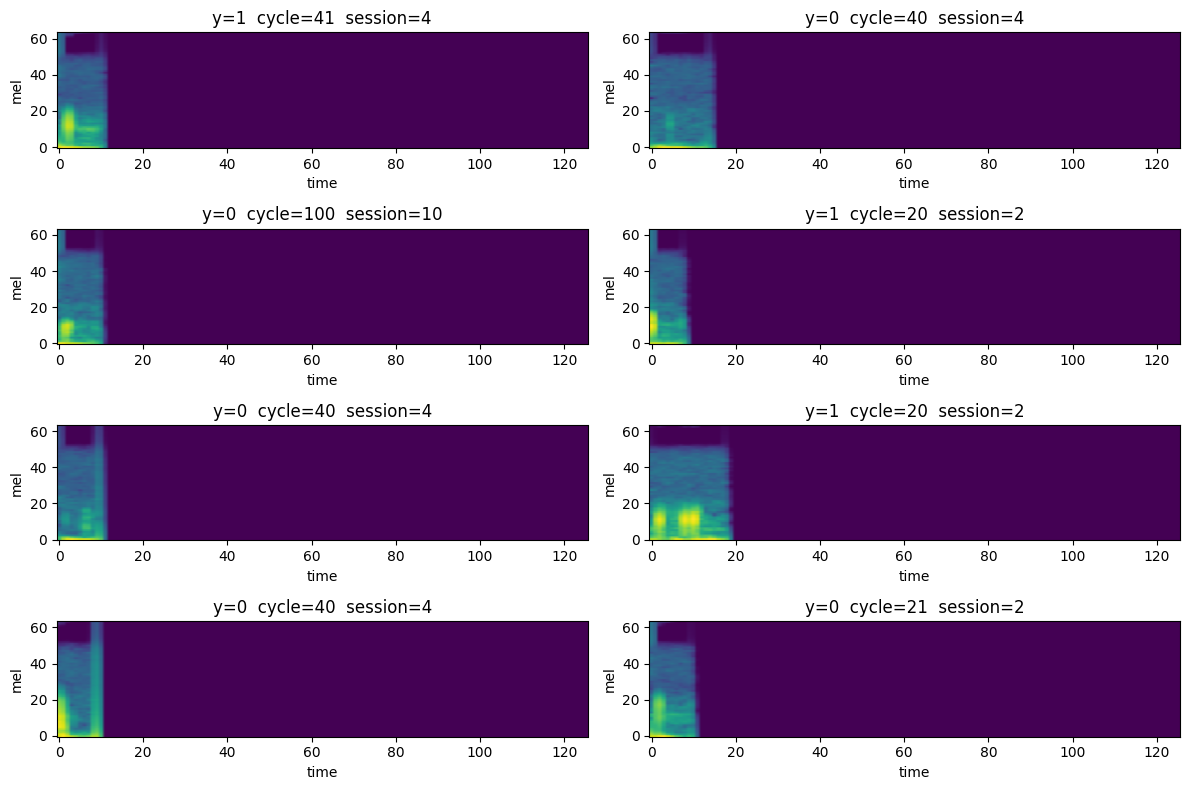

Epoch 01 | tr_loss=0.6747 | va_loss=0.6564 | va_acc=0.622 | va_auc=0.652
Epoch 02 | tr_loss=0.6723 | va_loss=0.6647 | va_acc=0.622 | va_auc=0.586
Epoch 03 | tr_loss=0.6700 | va_loss=0.6606 | va_acc=0.622 | va_auc=0.570
Epoch 04 | tr_loss=0.6694 | va_loss=0.6754 | va_acc=0.622 | va_auc=0.582
Epoch 05 | tr_loss=0.6684 | va_loss=0.6667 | va_acc=0.622 | va_auc=0.576
Epoch 06 | tr_loss=0.6687 | va_loss=0.6585 | va_acc=0.622 | va_auc=0.557
Epoch 07 | tr_loss=0.6655 | va_loss=0.6569 | va_acc=0.622 | va_auc=0.573
Epoch 08 | tr_loss=0.6616 | va_loss=0.6690 | va_acc=0.622 | va_auc=0.445
Epoch 09 | tr_loss=0.6552 | va_loss=0.7543 | va_acc=0.399 | va_auc=0.423
Epoch 10 | tr_loss=0.6575 | va_loss=0.6697 | va_acc=0.606 | va_auc=0.519


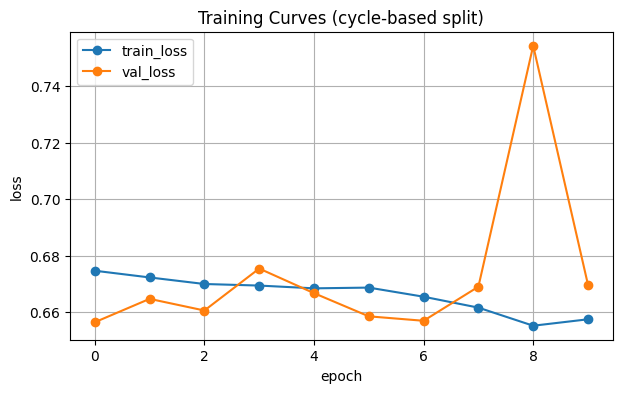

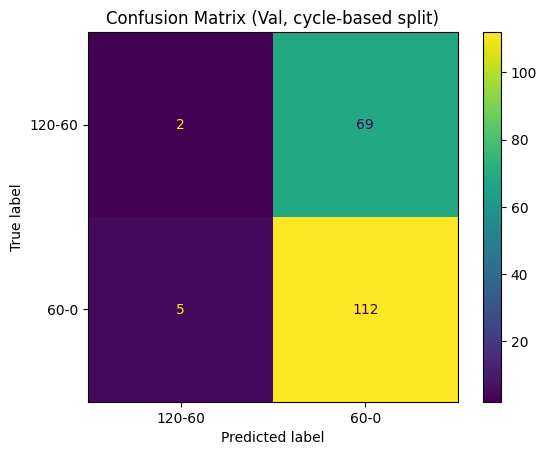

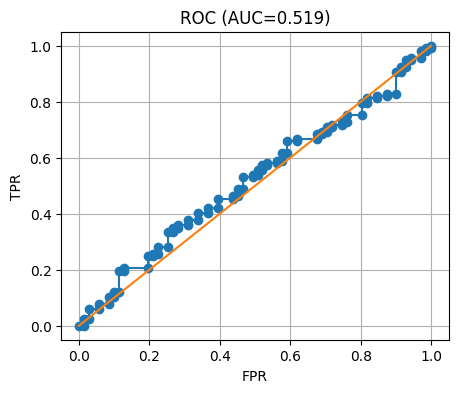

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



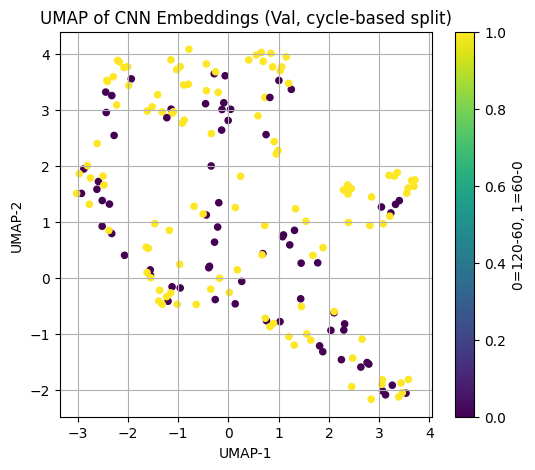

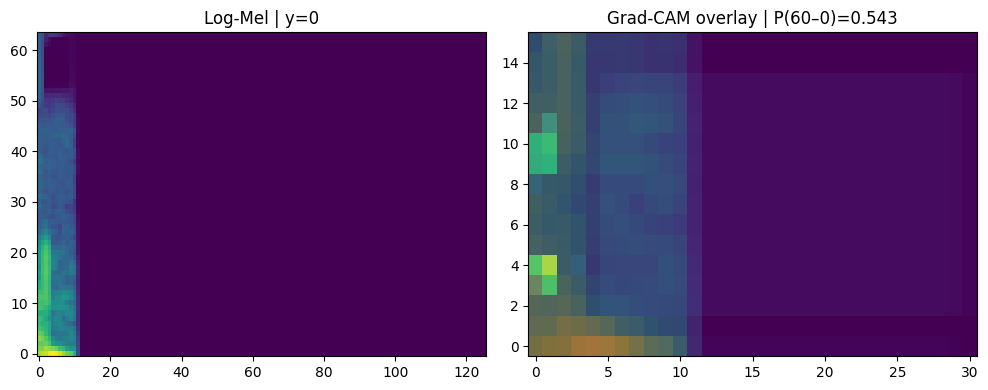

file: 10_29_2109_chunk_001.wav | cycle: 21 | session: 2


In [ ]:
# ============================================================
# LOG-MEL SPECTROGRAM CNN — CYCLE-BASED (NO LEAKAGE BY CYCLE)
# ============================================================

!pip -q install umap-learn

import os, random, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchaudio
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, accuracy_score
import umap

# =========================
# ✅ CELL 1: Build the 2-hour labeled dataset (NO leakage cycles)
# =========================

# ---- SETTINGS ----
TARGET_SR = 16000
MAX_SEC = 2.0
RANDOM_SEED = 42

assert "global_cycle_id" in data.columns, "global_cycle_id missing in data!"
assert "filename" in data.columns, "filename missing!"
assert "minutes_until_defecation" in data.columns, "minutes_until_defecation missing!"
assert "session_id" in data.columns, "session_id missing (needed only for metadata)"

df_cnn = data.copy()

# 2-hour window
df_cnn = df_cnn[df_cnn["minutes_until_defecation"] <= 120].copy()

# bins: 0-60 vs 60-120
df_cnn["y"] = np.where(df_cnn["minutes_until_defecation"] <= 60, 1, 0)  # 1 = near (60-0), 0 = 120-60

# wav path + existence
df_cnn["wav_path"] = df_cnn["filename"].apply(lambda f: os.path.join(CHUNKS_DIR, f))
df_cnn = df_cnn[df_cnn["wav_path"].apply(os.path.exists)].reset_index(drop=True)

print("Total samples:", len(df_cnn))
print("Class counts:\n", df_cnn["y"].value_counts())
print("Cycles:", df_cnn["global_cycle_id"].nunique())
print("Sessions (metadata):", df_cnn["session_id"].nunique())

# =========================
# ✅ CELL 2: Train/Val split (CYCLE-wise split to avoid leakage)
# =========================

all_cycles = sorted(df_cnn["global_cycle_id"].unique())
random.seed(RANDOM_SEED)
random.shuffle(all_cycles)

# hold out ~20% cycles (or at least 2)
n_val = max(2, int(0.2 * len(all_cycles)))
val_cycles = all_cycles[:n_val]
train_cycles = all_cycles[n_val:]

train_df = df_cnn[df_cnn["global_cycle_id"].isin(train_cycles)].reset_index(drop=True)
val_df   = df_cnn[df_cnn["global_cycle_id"].isin(val_cycles)].reset_index(drop=True)

print("\nTrain cycles:", len(train_cycles), "N:", len(train_df))
print("Val cycles:", len(val_cycles), "N:", len(val_df))
print("Train class counts:\n", train_df["y"].value_counts())
print("Val class counts:\n", val_df["y"].value_counts())

# =========================
# ✅ CELL 3: Dataset with Log-Mel Spectrogram
# =========================

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=TARGET_SR,
    n_fft=1024,
    hop_length=256,
    n_mels=64,
    f_min=20,
    f_max=TARGET_SR//2
)

def load_wav(path):
    wav, sr = torchaudio.load(path)
    wav = wav.mean(dim=0, keepdim=True)  # mono [1, T]
    if sr != TARGET_SR:
        wav = torchaudio.functional.resample(wav, sr, TARGET_SR)
    max_len = int(TARGET_SR * MAX_SEC)
    if wav.shape[1] < max_len:
        pad = max_len - wav.shape[1]
        wav = F.pad(wav, (0, pad))
    else:
        wav = wav[:, :max_len]
    return wav  # [1, T]

class MelDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = load_wav(row["wav_path"])
        M = mel(wav) + 1e-9
        logM = torch.log(M)

        # per-sample normalization
        logM = (logM - logM.mean()) / (logM.std() + 1e-6)

        y = torch.tensor(int(row["y"])).long()

        # return cycle_id + session_id for metadata/debug
        return logM, y, int(row["global_cycle_id"]), int(row["session_id"]), row["filename"]

# =========================
# ✅ CELL 4: Quick visualization (log-Mel)
# =========================

ds_tmp = MelDataset(df_cnn.sample(8, random_state=RANDOM_SEED))
plt.figure(figsize=(12,8))
for i in range(8):
    x, y, cid, sid, fn = ds_tmp[i]
    ax = plt.subplot(4,2,i+1)
    ax.imshow(x.squeeze(0).numpy(), aspect="auto", origin="lower")
    ax.set_title(f"y={int(y)}  cycle={cid}  session={sid}")
    ax.set_xlabel("time")
    ax.set_ylabel("mel")
plt.tight_layout()
plt.show()

# =========================
# ✅ CELL 5: CNN model
# =========================

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)
        self.bn3 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.25)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(64, 2)

    def forward(self, x, return_emb=False):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        emb = self.gap(x).squeeze(-1).squeeze(-1)  # [B,64]
        out = self.fc(emb)
        if return_emb:
            return out, emb
        return out

model = SmallCNN().to(DEVICE)

# =========================
# ✅ CELL 6: Train
# =========================

train_loader = DataLoader(MelDataset(train_df), batch_size=32, shuffle=True, num_workers=0)
val_loader   = DataLoader(MelDataset(val_df), batch_size=32, shuffle=False, num_workers=0)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train(train)
    losses, ys, ps = [], [], []
    for x, y, *_ in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if train:
            opt.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        if train:
            loss.backward()
            opt.step()
        losses.append(loss.item())
        prob = torch.softmax(logits, dim=1)[:,1].detach().cpu().numpy()
        ys.extend(y.detach().cpu().numpy())
        ps.extend(prob)
    return float(np.mean(losses)), np.array(ys), np.array(ps)

history = {"tr_loss":[], "va_loss":[], "va_auc":[], "va_acc":[]}

for epoch in range(1, 11):
    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, y_true, p1 = run_epoch(val_loader, train=False)
    y_pred = (p1 >= 0.5).astype(int)
    auc = roc_auc_score(y_true, p1) if len(np.unique(y_true)) > 1 else np.nan
    acc = accuracy_score(y_true, y_pred)

    history["tr_loss"].append(tr_loss)
    history["va_loss"].append(va_loss)
    history["va_auc"].append(auc)
    history["va_acc"].append(acc)

    print(f"Epoch {epoch:02d} | tr_loss={tr_loss:.4f} | va_loss={va_loss:.4f} | va_acc={acc:.3f} | va_auc={auc:.3f}")

# =========================
# ✅ CELL 7: Metrics visualization (loss, ROC, confusion matrix)
# =========================

plt.figure(figsize=(7,4))
plt.plot(history["tr_loss"], marker="o", label="train_loss")
plt.plot(history["va_loss"], marker="o", label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.grid(True)
plt.title("Training Curves (cycle-based split)")
plt.show()

_, y_true, p1 = run_epoch(val_loader, train=False)
y_pred = (p1 >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["120-60","60-0"])
disp.plot()
plt.title("Confusion Matrix (Val, cycle-based split)")
plt.show()

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, p1)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, marker="o")
    plt.plot([0,1],[0,1])
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC (AUC={roc_auc_score(y_true, p1):.3f})")
    plt.grid(True)
    plt.show()

# =========================
# 🧠 “See inside” 1: UMAP of embeddings (Val)
# =========================

def collect_embeddings(loader):
    model.eval()
    embs, ys, cids = [], [], []
    with torch.no_grad():
        for x, y, cid, *_ in loader:
            x = x.to(DEVICE)
            logits, emb = model(x, return_emb=True)
            embs.append(emb.cpu().numpy())
            ys.append(y.numpy())
            cids.append(cid.numpy())
    return np.vstack(embs), np.concatenate(ys), np.concatenate(cids)

emb_val, yv, cidv = collect_embeddings(val_loader)

um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM_SEED)
Z = um.fit_transform(emb_val)

plt.figure(figsize=(6,5))
plt.scatter(Z[:,0], Z[:,1], c=yv, s=20)
plt.title("UMAP of CNN Embeddings (Val, cycle-based split)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.colorbar(label="0=120-60, 1=60-0")
plt.grid(True)
plt.show()

# =========================
# 🔥 “See inside” 2: Grad-CAM on Mel Spectrogram
# =========================

def gradcam_single(sample_x):
    model.eval()
    x = sample_x.unsqueeze(0).to(DEVICE)

    feats = None
    grads = None

    def fwd_hook(module, inp, out):
        nonlocal feats
        feats = out

    def bwd_hook(module, grad_in, grad_out):
        nonlocal grads
        grads = grad_out[0]

    h1 = model.conv3.register_forward_hook(fwd_hook)
    h2 = model.conv3.register_full_backward_hook(bwd_hook)

    logits = model(x)
    score = torch.softmax(logits, dim=1)[0,1]
    model.zero_grad()
    score.backward()

    h1.remove(); h2.remove()

    w = grads.mean(dim=(2,3), keepdim=True)
    cam = (w * feats).sum(dim=1, keepdim=False)
    cam = F.relu(cam).squeeze(0).detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-9)
    return cam, float(score.detach().cpu())

ds_val = MelDataset(val_df)
x0, y0, cid0, sid0, fn0 = ds_val[0]
cam, prob = gradcam_single(x0)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(x0.squeeze(0).numpy(), aspect="auto", origin="lower")
plt.title(f"Log-Mel | y={int(y0)}")
plt.subplot(1,2,2)
plt.imshow(x0.squeeze(0).numpy(), aspect="auto", origin="lower")
plt.imshow(cam, aspect="auto", origin="lower", alpha=0.5)
plt.title(f"Grad-CAM overlay | P(60–0)={prob:.3f}")
plt.tight_layout()
plt.show()

print("file:", fn0, "| cycle:", cid0, "| session:", sid0)

Last-6h events: 2871
Cycles: 10
Sessions (metadata): 7
Computed dom-freq rows: 2871


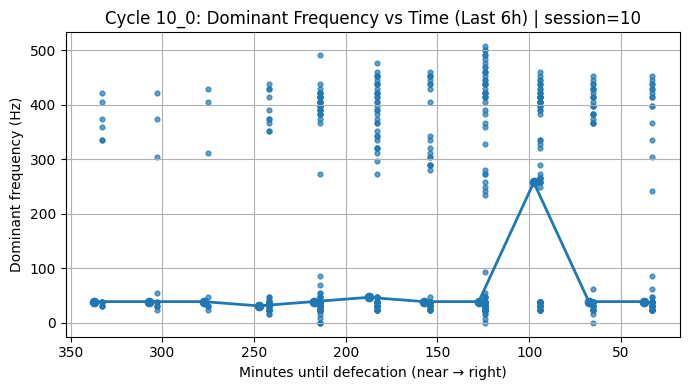

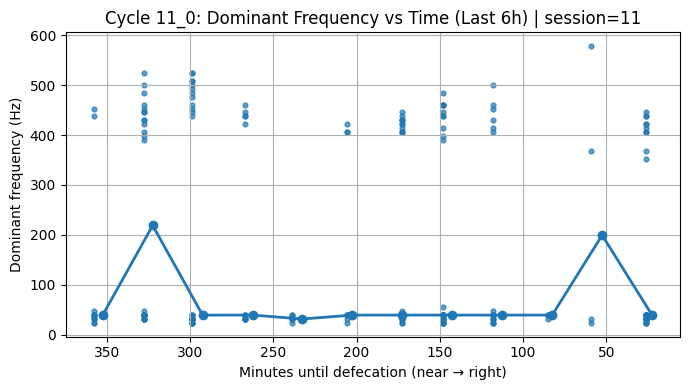

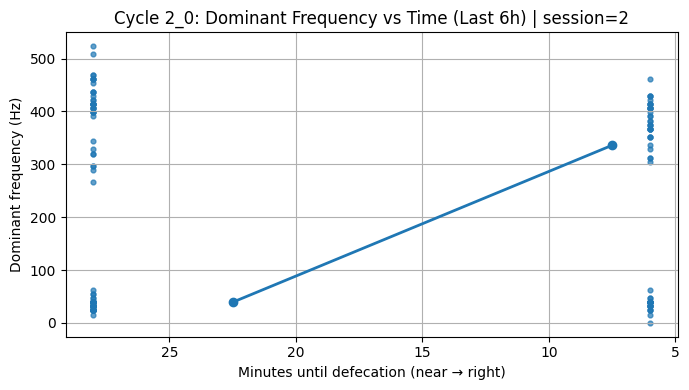

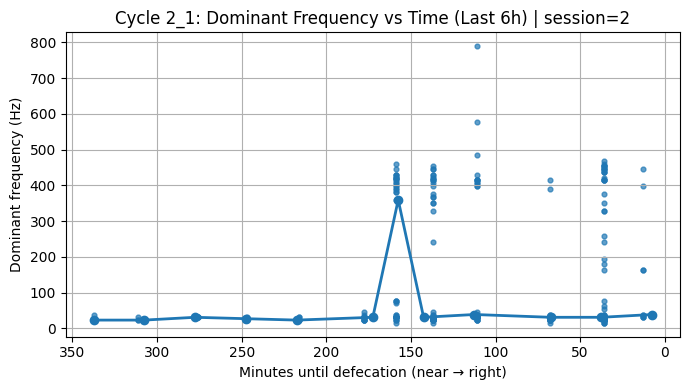

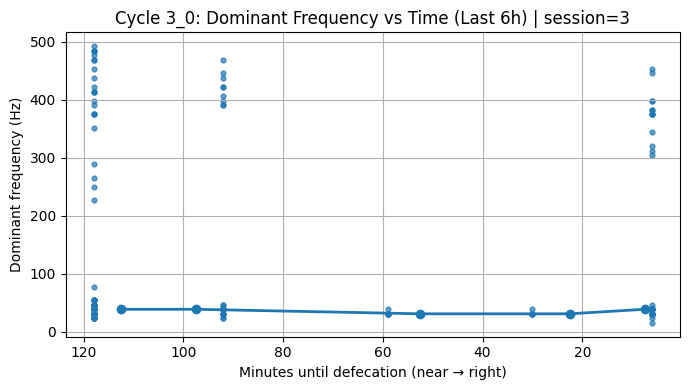

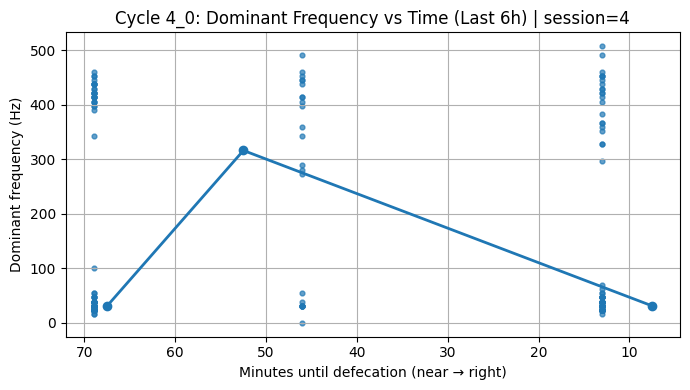

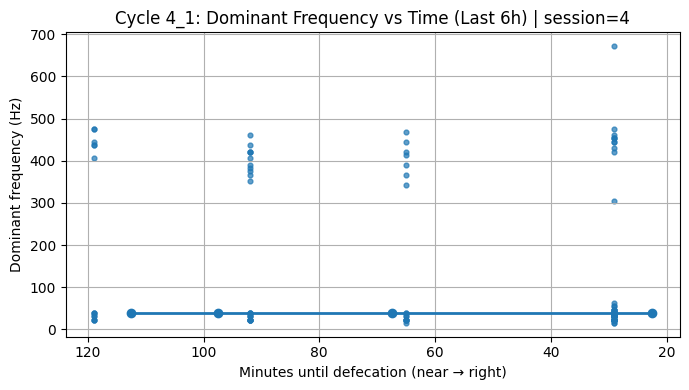

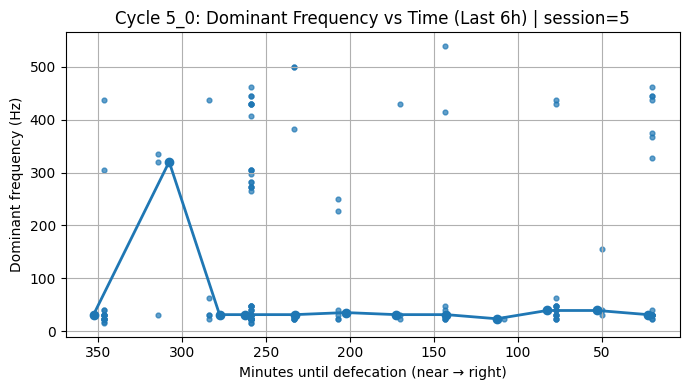

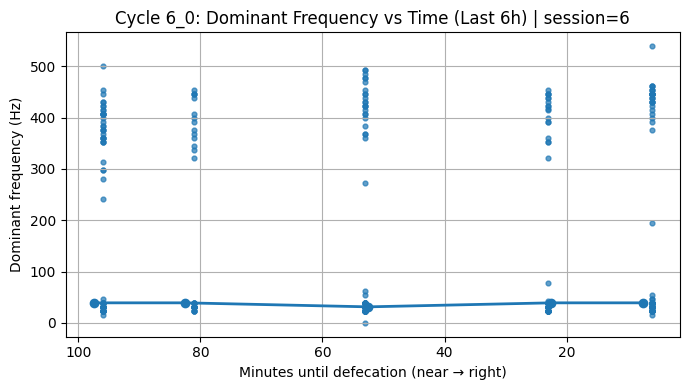

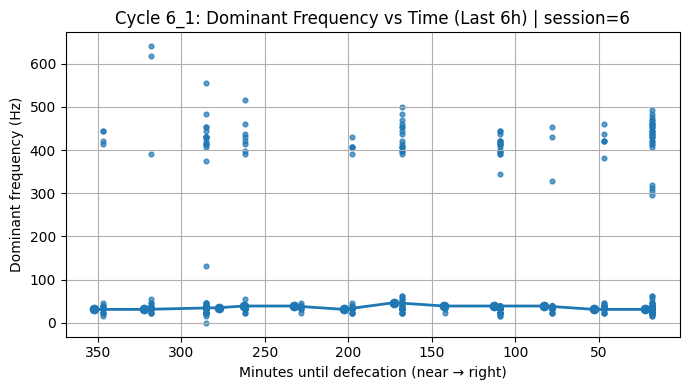

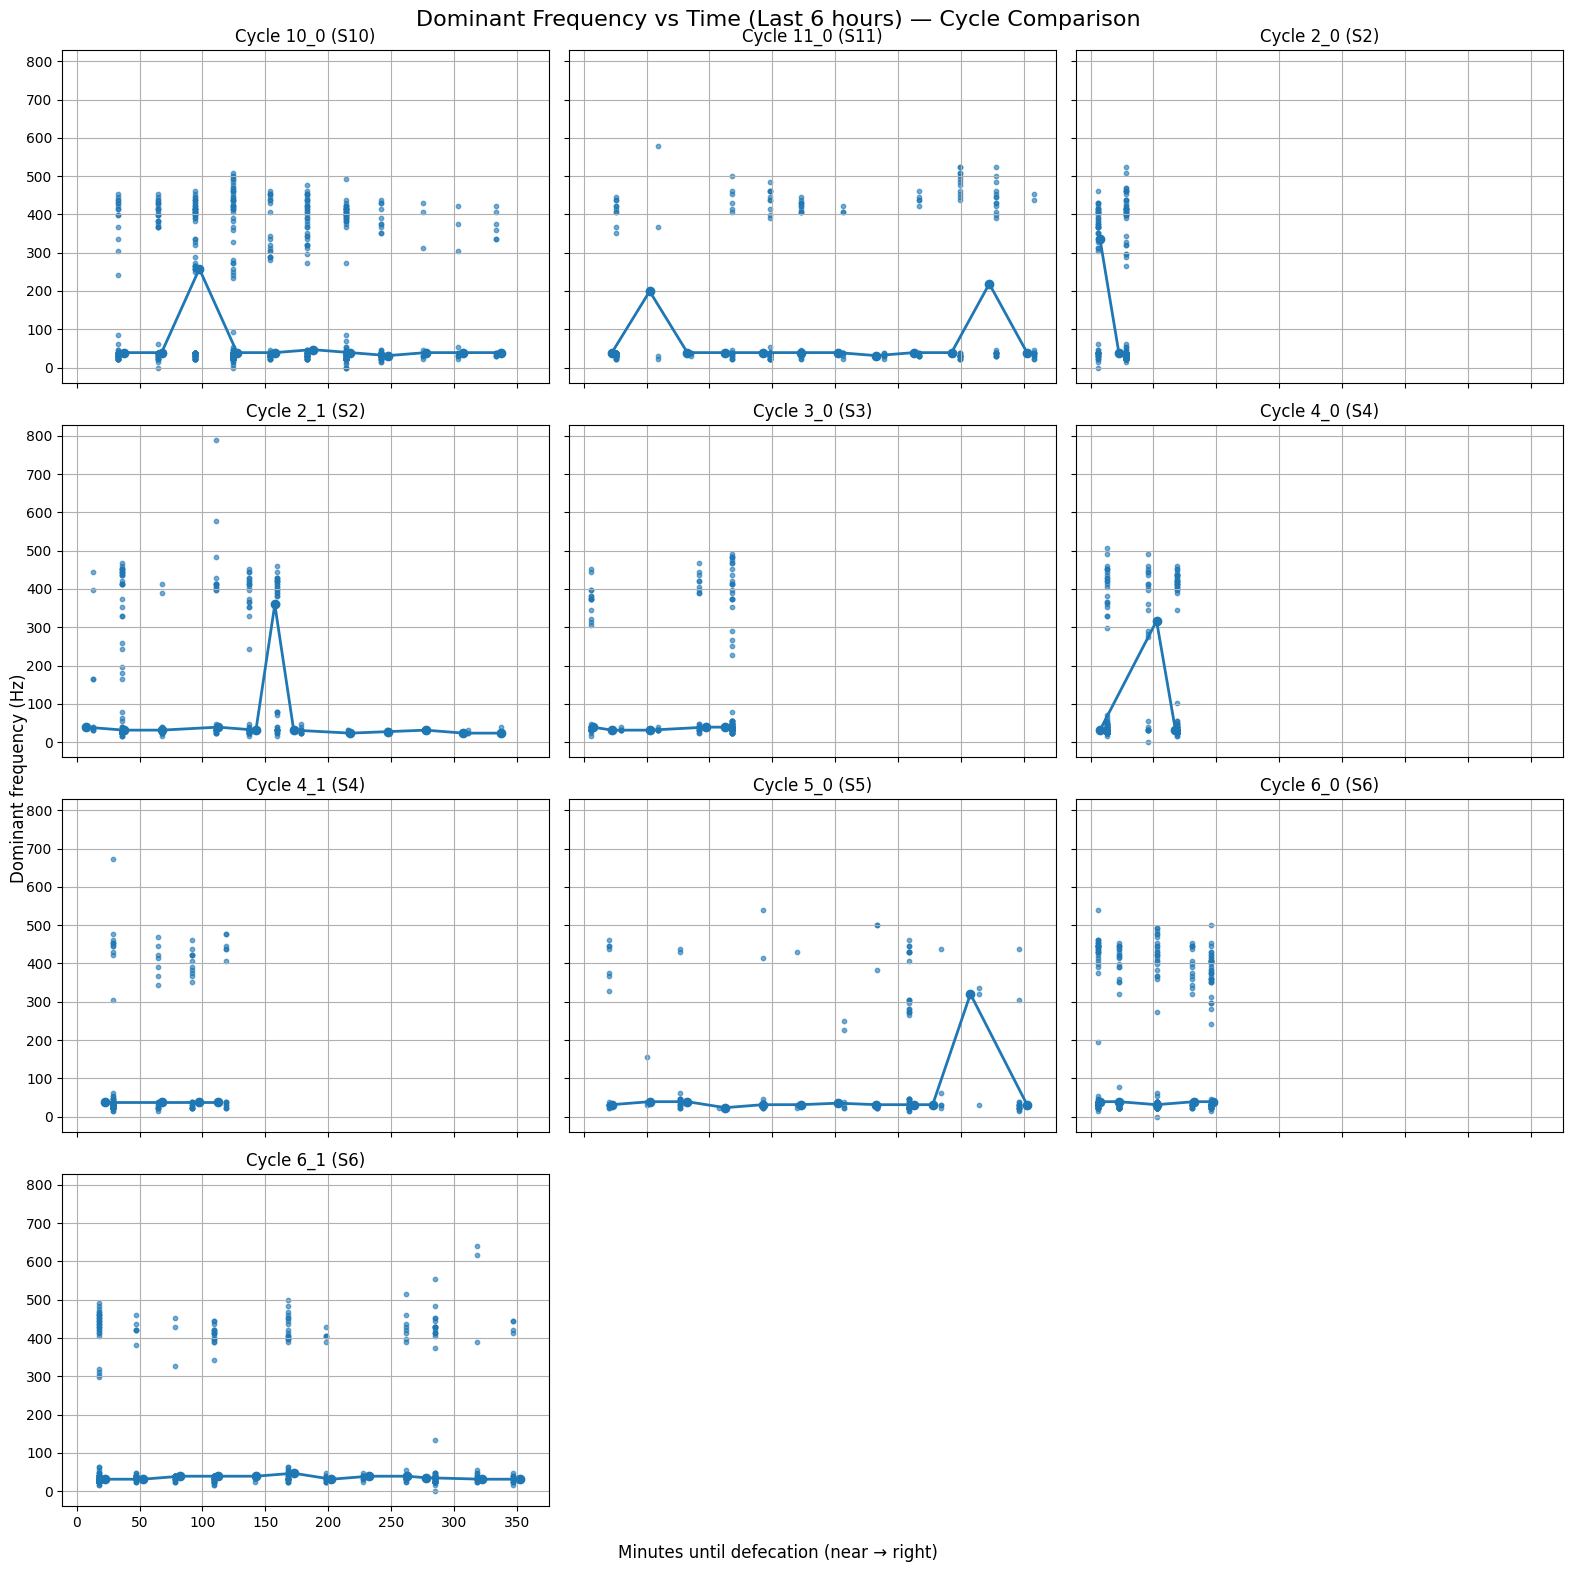

In [ ]:
# “frequency vs time” fingerprint for the last 6 hours of each CYCLE (cycle-based)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import soundfile as sf
from scipy import signal

# -----------------------------
# SETTINGS
# -----------------------------
LAST_HOURS_MIN = 360
HP_CUTOFF_HZ = 20      # change to 80 if needed
HP_ORDER = 2
MAX_DOMFREQ = 1000
N_BINS = 25            # number of time bins for median trend line

# -----------------------------
# Helpers
# -----------------------------
def highpass_np(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER):
    if len(x) < 64 or sr < 100:
        return x
    nyq = sr / 2
    if cutoff_hz <= 0 or cutoff_hz >= nyq:
        return x
    b, a = signal.butter(order, cutoff_hz / nyq, btype="highpass")
    return signal.filtfilt(b, a, x)

def dominant_freq_welch(x, sr):
    if len(x) < 256:
        return np.nan
    nperseg = min(1024, len(x))
    f, Pxx = signal.welch(x, fs=sr, nperseg=nperseg)
    if len(Pxx) == 0:
        return np.nan
    return float(f[np.argmax(Pxx)])

# -----------------------------
# 1) Filter last 6 hours
# -----------------------------
df6 = data.copy()

assert "global_cycle_id" in df6.columns, "global_cycle_id missing in data!"
assert "minutes_until_defecation" in df6.columns, "minutes_until_defecation missing!"
assert "filename" in df6.columns, "filename missing!"

df6 = df6[df6["minutes_until_defecation"] <= LAST_HOURS_MIN].copy()

df6["wav_path"] = df6["filename"].apply(lambda f: os.path.join(CHUNKS_DIR, f))
df6 = df6[df6["wav_path"].apply(os.path.exists)].copy()

print("Last-6h events:", len(df6))
print("Cycles:", df6["global_cycle_id"].nunique())
if "session_id" in df6.columns:
    print("Sessions (metadata):", df6["session_id"].nunique())

# -----------------------------
# 2) Compute dominant frequency (event-level)
# -----------------------------
domfreq = []
for p in df6["wav_path"].values:
    x, sr = sf.read(p)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)
    x = highpass_np(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER)
    domfreq.append(dominant_freq_welch(x, sr))

df6["dom_freq_hz"] = domfreq
df6 = df6.dropna(subset=["dom_freq_hz"]).copy()
df6 = df6[df6["dom_freq_hz"] <= MAX_DOMFREQ].copy()

print("Computed dom-freq rows:", len(df6))

# Common bins (0..360)
time_bins = np.linspace(0, LAST_HOURS_MIN, N_BINS)

# -----------------------------
# 3A) Plot each cycle
# -----------------------------
cycles = sorted(df6["global_cycle_id"].unique())

for cid in cycles:
    g = df6[df6["global_cycle_id"] == cid].sort_values("minutes_until_defecation").copy()
    if len(g) < 10:
        continue

    sid = g["session_id"].iloc[0] if "session_id" in g.columns else None

    plt.figure(figsize=(7,4))
    plt.scatter(g["minutes_until_defecation"], g["dom_freq_hz"], s=12, alpha=0.7)

    # Median trend line using bins
    g["bin"] = pd.cut(g["minutes_until_defecation"], bins=time_bins, include_lowest=True)
    med = g.groupby("bin", observed=True)["dom_freq_hz"].median().dropna()

    # centers computed ONLY for bins that exist
    centers = np.array([interval.mid for interval in med.index.astype(object)])
    plt.plot(centers, med.values, marker="o", linewidth=2)

    plt.gca().invert_xaxis()  # near event on right
    title = f"Cycle {cid}: Dominant Frequency vs Time (Last 6h)"
    if sid is not None:
        title += f" | session={sid}"
    plt.title(title)
    plt.xlabel("Minutes until defecation (near → right)")
    plt.ylabel("Dominant frequency (Hz)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3B) Grid view (cycle comparison)
# -----------------------------
cycles = sorted(df6["global_cycle_id"].unique())
n = len(cycles)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

plot_i = -1
for i, cid in enumerate(cycles):
    g = df6[df6["global_cycle_id"] == cid].sort_values("minutes_until_defecation").copy()
    if len(g) < 10:
        continue

    plot_i += 1
    ax = axes[plot_i]

    ax.scatter(g["minutes_until_defecation"], g["dom_freq_hz"], s=10, alpha=0.6)

    g["bin"] = pd.cut(g["minutes_until_defecation"], bins=time_bins, include_lowest=True)
    med = g.groupby("bin", observed=True)["dom_freq_hz"].median().dropna()
    centers = np.array([interval.mid for interval in med.index.astype(object)])

    ax.plot(centers, med.values, marker="o", linewidth=2)
    sid = g["session_id"].iloc[0] if "session_id" in g.columns else None
    ax.set_title(f"Cycle {cid}" + (f" (S{sid})" if sid is not None else ""))
    ax.grid(True)
    ax.invert_xaxis()

# Hide unused axes
for j in range(plot_i+1, len(axes)):
    axes[j].axis("off")

fig.suptitle("Dominant Frequency vs Time (Last 6 hours) — Cycle Comparison", fontsize=16)
fig.supxlabel("Minutes until defecation (near → right)")
fig.supylabel("Dominant frequency (Hz)")
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning:

invalid escape sequence '\{'



Pool size (events): 4839
Pool size (cycles): 16
Subset size (events): 448
Subset size (cycles): 16
                   filename  session_id global_cycle_id  \
0  11_21_1901_chunk_056.wav          10            10_0   
1  11_21_1831_chunk_118.wav          10            10_0   
2  11_21_2002_chunk_008.wav          10            10_0   
3  11_21_1732_chunk_052.wav          10            10_0   
4  11_21_1633_chunk_047.wav          10            10_0   

   minutes_until_defecation  
0                      94.0  
1                     124.0  
2                      33.0  
3                     183.0  
4                     242.0  


/tmp/ipykernel_1503/2829150135.py:48: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Saved: results_code_set4/subset_cycles16_seed42.csv
Saved listen list: results_code_set4/subset_cycles16_seed42_listenlist.csv
Missing columns: []
Rows after NaN removal: 448
Feature matrix shape: (448, 6)


,feat_centroid_mean,feat_flatness_mean,feat_roll95_amp_mean,feat_duration_s,feat_tkeo_mean,feat_flux_mean
0,391.874201,0.178755,2171.875000,0.15,9.254840e-09,0.000142
1,416.782154,0.205941,2378.125000,0.13,1.450564e-07,0.000139
2,414.349575,0.168426,1851.562500,0.24,3.968886e-08,0.000302
3,491.266410,0.177858,1479.910767,0.17,2.238618e-08,0.000222
4,456.055064,0.183581,1890.625000,0.16,1.038337e-07,0.000316


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP shape: (448, 2)


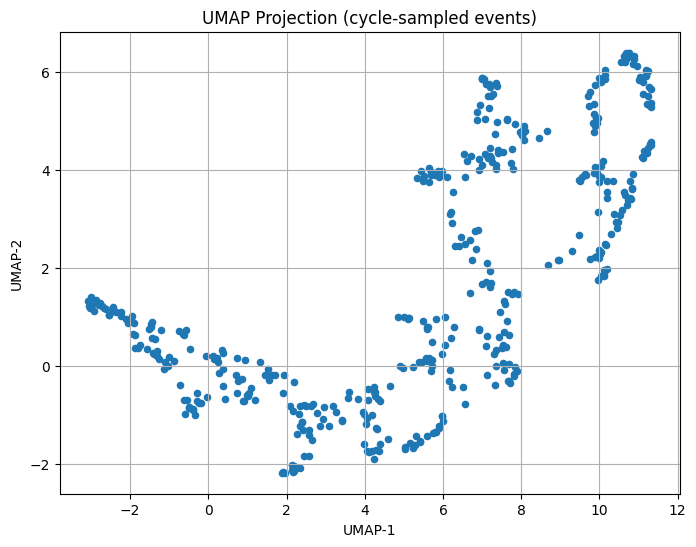

Cluster counts:
cluster
-1    238
 1    174
 0     36
Name: count, dtype: int64


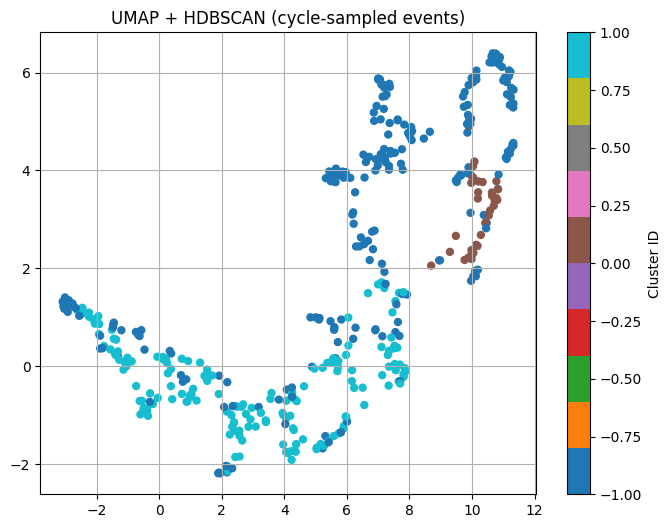


Event-level cluster feature means:


,feat_centroid_mean,feat_flatness_mean,feat_roll95_amp_mean,feat_duration_s,feat_tkeo_mean,feat_flux_mean
cluster,,,,,,
0,263.619918,0.097854,1230.305469,0.151111,1.988355e-07,0.000473
1,450.675986,0.192469,2046.480309,0.152874,7.331063e-08,0.000249



Event counts per cluster:
cluster
1    174
0     36
Name: count, dtype: int64

Unique cycles per cluster:


,N_cycles
cluster,
0,14
1,16



Cluster summary using per-cycle medians:


,feat_centroid_mean,feat_flatness_mean,feat_roll95_amp_mean,feat_duration_s,feat_tkeo_mean,feat_flux_mean
cluster,,,,,,
0,264.432723,0.097478,1216.563030,0.150714,3.037854e-07,0.000494
1,440.513656,0.188471,2075.567341,0.150000,3.471623e-08,0.000225


In [ ]:
# ============================================================
# CYCLE-BASED: Sample N cycles (then events) → UMAP + HDBSCAN
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
N_CYCLES = 300   # sample 300 cycles (recommended for cycle-based)
MAX_EVENTS_PER_CYCLE = 30  # cap events per cycle so one big cycle doesn't dominate
PAD_VALUE = 0.0

# Use normalized features for clustering (recommended)
df_pool = data_norm.copy()

assert "global_cycle_id" in df_pool.columns, "global_cycle_id missing in data_norm!"
assert "minutes_until_defecation" in df_pool.columns, "minutes_until_defecation missing!"
assert "filename" in df_pool.columns, "filename missing!"
assert "session_id" in df_pool.columns, "session_id missing!"

# keep only rows that have valid time
df_pool = df_pool[df_pool["minutes_until_defecation"].notna()].copy()

print("Pool size (events):", len(df_pool))
print("Pool size (cycles):", df_pool["global_cycle_id"].nunique())

# ------------------------------------------------------------
# STEP 1: Sample cycles, then sample events from each cycle
# ------------------------------------------------------------
cycles = df_pool["global_cycle_id"].dropna().unique()
rng = np.random.default_rng(RANDOM_SEED)

if len(cycles) <= N_CYCLES:
    sampled_cycles = cycles
else:
    sampled_cycles = rng.choice(cycles, size=N_CYCLES, replace=False)

subset = df_pool[df_pool["global_cycle_id"].isin(sampled_cycles)].copy()

# cap per-cycle events (optional but strongly recommended)
subset = (
    subset.groupby("global_cycle_id", group_keys=False)
          .apply(lambda g: g.sample(n=min(len(g), MAX_EVENTS_PER_CYCLE), random_state=RANDOM_SEED))
          .reset_index(drop=True)
)

print("Subset size (events):", len(subset))
print("Subset size (cycles):", subset["global_cycle_id"].nunique())
print(subset[["filename", "session_id", "global_cycle_id", "minutes_until_defecation"]].head())

# Save subset CSV
subset_csv = os.path.join(OUT_DIR, f"subset_cycles{len(sampled_cycles)}_seed{RANDOM_SEED}.csv")
subset.to_csv(subset_csv, index=False)
print("Saved:", subset_csv)

# Add wav path for listening
subset["wav_path"] = subset["filename"].apply(lambda f: os.path.join(CHUNKS_DIR, f))

listen_csv = os.path.join(OUT_DIR, f"subset_cycles{len(sampled_cycles)}_seed{RANDOM_SEED}_listenlist.csv")
subset[["filename", "session_id", "global_cycle_id", "minutes_until_defecation", "wav_path"]].to_csv(listen_csv, index=False)
print("Saved listen list:", listen_csv)

# ------------------------------------------------------------
# STEP 2: Build feature matrix
# ------------------------------------------------------------
FEATURE_COLS = [
    "feat_centroid_mean",
    "feat_flatness_mean",
    "feat_roll95_amp_mean",
    "feat_duration_s",
    "feat_tkeo_mean",
    "feat_flux_mean",
]

missing = [c for c in FEATURE_COLS if c not in subset.columns]
print("Missing columns:", missing)

df_features = subset.dropna(subset=FEATURE_COLS).copy()
print("Rows after NaN removal:", len(df_features))

X = df_features[FEATURE_COLS].values
print("Feature matrix shape:", X.shape)
display(df_features[FEATURE_COLS].head())

# ------------------------------------------------------------
# STEP 3A: UMAP projection
# ------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=RANDOM_SEED
)
X_umap = umap_model.fit_transform(X_scaled)
print("UMAP shape:", X_umap.shape)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], s=20)
plt.title("UMAP Projection (cycle-sampled events)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# STEP 3B: HDBSCAN clustering
# ------------------------------------------------------------
clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
labels = clusterer.fit_predict(X_scaled)

df_features["cluster"] = labels

print("Cluster counts:")
print(df_features["cluster"].value_counts())

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_umap[:,0], X_umap[:,1], c=labels, cmap="tab10", s=25)
plt.colorbar(scatter, label="Cluster ID")
plt.title("UMAP + HDBSCAN (cycle-sampled events)")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Cluster summaries (event-level + cycle-level)
# ------------------------------------------------------------
df_clustered = df_features[df_features["cluster"] != -1].copy()

print("\nEvent-level cluster feature means:")
display(df_clustered.groupby("cluster")[FEATURE_COLS].mean())

print("\nEvent counts per cluster:")
print(df_clustered["cluster"].value_counts())

# Cycle-level: how many unique cycles contribute to each cluster?
cycle_counts = df_clustered.groupby("cluster")["global_cycle_id"].nunique().rename("N_cycles")
print("\nUnique cycles per cluster:")
display(cycle_counts)

# Optional: per-cycle median features then cluster summary by those (reduces repetition effect)
cycle_meds = (
    df_clustered.groupby(["cluster", "global_cycle_id"], observed=True)[FEATURE_COLS]
               .median()
               .reset_index()
)
print("\nCluster summary using per-cycle medians:")
display(cycle_meds.groupby("cluster")[FEATURE_COLS].mean())